<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Алексей, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>
 
<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

  
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  

<br/>
<div class="alerфt alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# Модель для прогнозирования оттока клиентов Happy Beans Coffee

**Цель проекта:** построить модель бинарной классификации, которая предсказывает вероятность оттока клиента (`churn`) на основе агрегированных признаков за последние 4 недели.

**Бизнес-задача:** заранее находить клиентов с высоким риском ухода, чтобы команда маркетинга могла запускать удерживающие коммуникации, персональные предложения и улучшать клиентский опыт.

**Особенности данных:** каждая строка соответствует одному уникальному клиенту. Датасет уже является аналитической витриной: поведенческие, транзакционные, продуктовые и технические признаки заранее агрегированы на уровне пользователя.

**Автор** Бровкин Алексей

**Дата** 01.06.2026

# План работы

1. Подготовить среду, загрузить данные и зафиксировать `random_state`.
2. Выполнить первичный и исследовательский анализ данных.
3. Проверить пропуски, дубликаты, выбросы, распределение целевого признака и связь признаков с оттоком.
4. Разделить данные на обучающую и тестовую выборки со стратификацией.
5. Собрать пайплайн предобработки: заполнение пропусков, ограничение выбросов, масштабирование числовых признаков, кодирование категориальных признаков.
6. Обучить baseline-модели и оценить их с помощью кросс-валидации.
7. Создать новые признаки, сравнить качество модели до и после feature engineering.
8. Провести систематический подбор гиперпараметров для логистической регрессии.
9. Обучить финальную модель на всех обучающих данных и проверить качество на отложенной тестовой выборке.
10. Сохранить модель, пайплайн и отчётные артефакты для дальнейшего использования.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию, цели и задачи ясны.


## Этап 1. Подготовка среды и библиотек

На этом этапе импортируем библиотеки, зададим константы и загрузим датасет. В проекте используется фиксированный `RANDOM_STATE`, чтобы результаты разбиения выборок, кросс-валидации и обучения модели были воспроизводимыми.

In [1]:
import os
import sys
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 3

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print('Библиотеки импортированы.')

Библиотеки импортированы.


In [2]:
# Фиксация версий всех установленных пакетов для воспроизводимости проекта
#!pip freeze > requirements.txt

#print('Файл requirements.txt создан.')

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все верно. Единственное, эта команда нам нужна только для того, чтобы зафиксировать, записать в документ и сохранить зависимости. Дальше мы можем просто взять requirements.txt и разместить в репозитории (например, гитхаб) вместе с нашей моделью.
    
Поэтому вполне логично было бы один раз эту команду запустить, а потом либо убрать, либо закомментировать.
    
Смысл задания именно в том, чтобы сохранить модель + зависимости и дать на них ссылку. 



In [3]:
# Для локальной проверки используем файл из текущей директории или /mnt/data.
possible_paths = [
    '/datasets/coffee_churn_dataset.csv',
    'coffee_churn_dataset.csv',
    '/Users/aleksej/Яндекс практикум/Спринт 12/coffee_churn_dataset.csv'
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError('Файл coffee_churn_dataset.csv не найден. Проверьте путь к данным.')

data = pd.read_csv(DATA_PATH, sep=',', decimal='.')

print(f'Файл загружен: {DATA_PATH}')
print(f'Размер датасета: {data.shape[0]} строк × {data.shape[1]} столбцов')
display(data.head())

Файл загружен: /Users/aleksej/Яндекс практикум/Спринт 12/coffee_churn_dataset.csv
Размер датасета: 10450 строк × 27 столбцов


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.000,12.943,NaN,316.834,260.645,3089.991,NaN,0.337,blend,light,almond,NaN,vietnam,large,pro,30.468,1.000,5.177,3.302,NaN,summer,6.000,android,0.000,geo_75,1
1,user_07234,2.000,1.569,0.214,780.135,540.598,998.381,107.369,0.548,arabica,light,whole,1.000,guatemala,medium,none,NaN,1.000,4.393,NaN,0.000,autumn,16.000,ios,0.000,geo_95,0
2,user_04816,11.000,2.997,0.772,682.636,471.495,1328.140,392.600,0.120,arabica,medium,oat,1.000,guatemala,small,premium,17.896,1.000,4.978,4.379,0.000,spring,11.000,web,1.000,geo_25,0
3,user_04419,0.000,4.299,1.210,2115.487,708.530,2999.628,1084.352,NaN,robusta,medium,skim,0.000,brazil,medium,none,11.406,1.000,3.713,3.044,0.000,summer,3.000,android,0.000,geo_2,0
4,user_09698,3.000,7.250,1.761,3519.602,1199.373,8377.729,2551.775,0.075,robusta,dark,almond,1.000,colombia,medium,none,15.948,0.000,4.528,5.643,1.000,winter,14.000,ios,0.000,geo_19,1


## Этап 2. Первичный и исследовательский анализ данных

На этом этапе необходимо понять, какие данные доступны для прогнозирования оттока, есть ли проблемы качества данных и какие решения потребуется перенести в пайплайн предобработки.

### 2.1. Описание данных и поведения клиентов

Датасет представляет собой готовую аналитическую витрину: одна строка соответствует одному клиенту, а признаки агрегированы за последние четыре недели. Данные описывают активность заказов, траты, использование скидок, предпочтения по кофе, взаимодействие с приложением, оценки, подписку, устройство, сезон и регион пользователя.

In [4]:
# Общая информация о данных
print(f'Размер датасета: {data.shape[0]} строк × {data.shape[1]} столбцов')
print(f'Уникальных пользователей: {data["user_id"].nunique()}')
print(f'Полных дубликатов: {data.duplicated().sum()}')
print(f'Повторяющихся user_id: {data["user_id"].duplicated().sum()}')

display(data.head())
display(data.info())
display(data.describe(include='all').T)

Размер датасета: 10450 строк × 27 столбцов
Уникальных пользователей: 10450
Полных дубликатов: 0
Повторяющихся user_id: 0


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.000,12.943,NaN,316.834,260.645,3089.991,NaN,0.337,blend,light,almond,NaN,vietnam,large,pro,30.468,1.000,5.177,3.302,NaN,summer,6.000,android,0.000,geo_75,1
1,user_07234,2.000,1.569,0.214,780.135,540.598,998.381,107.369,0.548,arabica,light,whole,1.000,guatemala,medium,none,NaN,1.000,4.393,NaN,0.000,autumn,16.000,ios,0.000,geo_95,0
2,user_04816,11.000,2.997,0.772,682.636,471.495,1328.140,392.600,0.120,arabica,medium,oat,1.000,guatemala,small,premium,17.896,1.000,4.978,4.379,0.000,spring,11.000,web,1.000,geo_25,0
3,user_04419,0.000,4.299,1.210,2115.487,708.530,2999.628,1084.352,NaN,robusta,medium,skim,0.000,brazil,medium,none,11.406,1.000,3.713,3.044,0.000,summer,3.000,android,0.000,geo_2,0
4,user_09698,3.000,7.250,1.761,3519.602,1199.373,8377.729,2551.775,0.075,robusta,dark,almond,1.000,colombia,medium,none,15.948,0.000,4.528,5.643,1.000,winter,14.000,ios,0.000,geo_19,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10450,10450,user_00318,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_order,9505.000,NaN,NaN,NaN,4.394,4.859,0.000,1.000,3.000,6.000,40.000
order_frequency_month,9850.000,NaN,NaN,NaN,4.026,2.826,0.011,1.938,3.381,5.439,27.389
order_frequency_week,10062.000,NaN,NaN,NaN,0.931,0.657,-0.169,0.445,0.785,1.262,6.303
avg_order_value,9867.000,NaN,NaN,NaN,1063.741,707.713,-32.076,552.899,898.644,1406.332,5901.965
median_order_value,9619.000,NaN,NaN,NaN,452.651,258.658,-10.353,262.909,406.457,590.418,2189.102
total_spent_last_month,10156.000,NaN,NaN,NaN,1946.133,2370.620,-43.716,629.680,1300.410,2481.650,79298.850
total_spent_last_week,9506.000,NaN,NaN,NaN,413.005,445.635,-2290.559,136.566,288.277,549.699,8615.989
discount_usage_rate,10053.000,NaN,NaN,NaN,0.284,0.159,0.002,0.160,0.265,0.387,0.887
last_coffee_type,10192,3,arabica,6134,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Вывод.** В датасете содержатся сведения о **10 450 уникальных клиентах** и 27 столбцах, включая целевой признак `churn`. Полных дубликатов и повторяющихся идентификаторов пользователей нет, следовательно, заявленная гранулярность витрины соблюдается: одна строка действительно описывает одного клиента. По признакам можно изучать частоту и давность заказов, траты, промо-поведение, предпочтения, пользовательский опыт в приложении и региональные различия.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно по первому знакомству с данными.

### 2.2. Целевая переменная `churn`

Целевая переменная бинарная:
- `0` — клиент продолжает пользоваться сервисом;
- `1` — клиент перестал пользоваться сервисом.

,count,share
0,9821,0.940
1,629,0.060


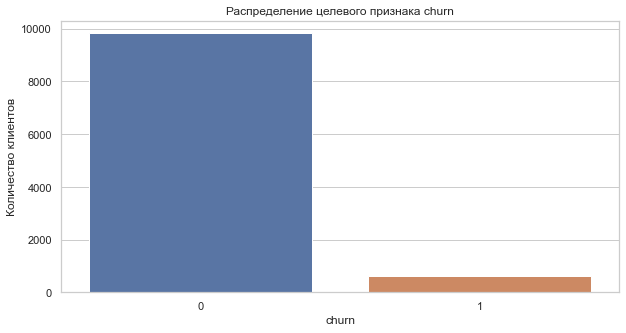

In [5]:
# Анализ целевой переменной
churn_counts = data['churn'].value_counts().rename('count').to_frame()
churn_counts['share'] = data['churn'].value_counts(normalize=True)
display(churn_counts)

ax = sns.countplot(data=data, x='churn')
ax.set_title('Распределение целевого признака churn')
ax.set_xlabel('churn')
ax.set_ylabel('Количество клиентов')
plt.show()

**Вывод по целевой переменной.** К классу оттока относятся **629 клиентов (6%)**, а к классу без оттока — **9 821 клиент (94%)**. Наблюдается выраженный дисбаланс классов. Поэтому `accuracy` не подходит как основная метрика: модель, всегда выдающая класс 0, получила бы высокую долю правильных ответов, но не обнаружила бы ни одного уходящего клиента. Основной метрикой выбора модели будет `PR-AUC`, дополнительно будут рассчитываться `ROC-AUC`, `Log Loss`, `Precision`, `Recall` и `F1`. 


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Дисбаланс есть и он существенный, впрочем это ожидаемо для задачи оттока




### 2.3. Описание и первичная оценка признаков

Разделим признаки по роли и определим, какие из них допустимо использовать при моделировании.

In [6]:
id_col = 'user_id'
target_col = 'churn'

numeric_features = data.drop(columns=[id_col, target_col]).select_dtypes(include='number').columns.tolist()
categorical_features = data.drop(columns=[id_col, target_col]).select_dtypes(exclude='number').columns.tolist()

feature_overview = pd.DataFrame({
    'feature': data.columns,
    'dtype': data.dtypes.astype(str).values,
    'missing_count': data.isna().sum().values,
    'unique_values': data.nunique(dropna=True).values,
})
feature_overview['role'] = 'numeric'
feature_overview.loc[feature_overview['feature'].isin(categorical_features), 'role'] = 'categorical'
feature_overview.loc[feature_overview['feature'] == id_col, 'role'] = 'identifier'
feature_overview.loc[feature_overview['feature'] == target_col, 'role'] = 'target'
feature_overview['decision'] = 'использовать'
feature_overview.loc[feature_overview['feature'] == id_col, 'decision'] = 'удалить до моделирования'
feature_overview.loc[feature_overview['feature'] == target_col, 'decision'] = 'целевая переменная'

display(feature_overview)
print('Числовые признаки:', len(numeric_features), numeric_features)
print('Категориальные признаки:', len(categorical_features), categorical_features)

,feature,dtype,missing_count,unique_values,role,decision
0,user_id,object,0,10450,identifier,удалить до моделирования
1,days_since_last_order,float64,945,39,numeric,использовать
2,order_frequency_month,float64,600,9419,numeric,использовать
3,order_frequency_week,float64,388,9625,numeric,использовать
4,avg_order_value,float64,583,9441,numeric,использовать
5,median_order_value,float64,831,9201,numeric,использовать
6,total_spent_last_month,float64,294,9713,numeric,использовать
7,total_spent_last_week,float64,944,9090,numeric,использовать
8,discount_usage_rate,float64,397,9618,numeric,использовать
9,last_coffee_type,object,258,3,categorical,использовать


Числовые признаки: 16 ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']
Категориальные признаки: 9 ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


**Решение по признакам.** `user_id` следует удалить перед обучением: это технический идентификатор, он не описывает поведение клиента и может привести к запоминанию объектов вместо выявления закономерностей. `churn` используется только как целевая переменная. Остальные признаки потенциально содержат информацию о пользовательской активности или профиле клиента и на этом этапе сохраняются. Некоторые числовые признаки могут оказаться избыточными из-за высокой корреляции; это будет проверено отдельно в корреляционном анализе.

### 2.4. Пропущенные значения

Проверим распространённость пропусков и оценим, допустимо ли удалять строки с отсутствующими значениями.

,missing_count,missing_share,missing_share_pct
seasonal_menu_tried,989,0.095,9.464
days_since_last_order,945,0.090,9.043
total_spent_last_week,944,0.090,9.033
subscription_status,938,0.090,8.976
app_opens_per_week,896,0.086,8.574
review_rating_last_1,857,0.082,8.201
median_order_value,831,0.080,7.952
days_since_last_promo,731,0.070,6.995
app_crashes_last_month,721,0.069,6.900
review_rating_last_10,693,0.066,6.632


Строк без пропусков: 2279 из 10450
При удалении всех строк с пропусками было бы потеряно: 8171 строк (78.19%)


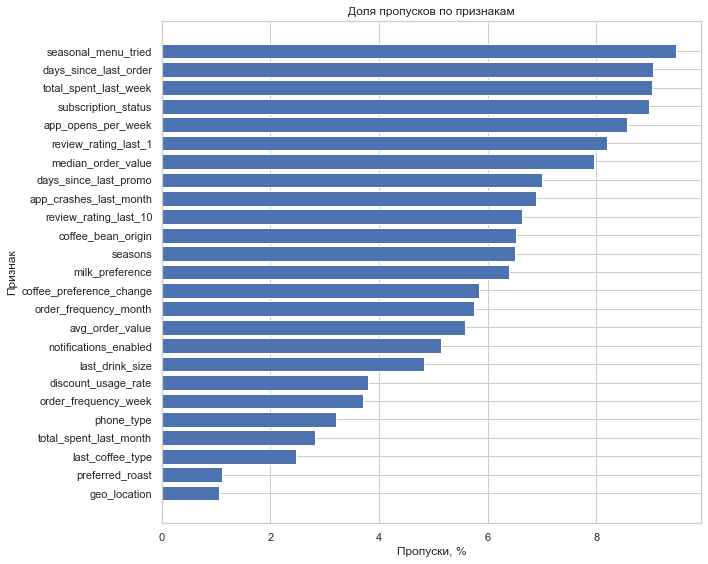

In [7]:
missing = data.isna().sum().to_frame('missing_count')
missing['missing_share'] = missing['missing_count'] / len(data)
missing['missing_share_pct'] = missing['missing_share'] * 100
missing = missing.sort_values('missing_count', ascending=False)

display(missing[missing['missing_count'] > 0])

rows_without_missing = data.dropna().shape[0]
removed_if_dropna = len(data) - rows_without_missing
print(f'Строк без пропусков: {rows_without_missing} из {len(data)}')
print(f'При удалении всех строк с пропусками было бы потеряно: {removed_if_dropna} строк '
      f'({removed_if_dropna / len(data):.2%})')

plot_missing = missing[missing['missing_count'] > 0].sort_values('missing_share_pct')
plt.figure(figsize=(10, 8))
plt.barh(plot_missing.index, plot_missing['missing_share_pct'])
plt.title('Доля пропусков по признакам')
plt.xlabel('Пропуски, %')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

**Вывод по пропускам.** Пропуски присутствуют во многих признаках. Максимальные доли отсутствующих значений наблюдаются в `seasonal_menu_tried` (9,46%), `days_since_last_order` (9,04%), `total_spent_last_week` (9,03%) и `subscription_status` (8,98%). Если удалить все неполные строки, останется только **2 279 из 10 450 клиентов**, то есть будет потеряно около **78,19%** выборки. Это недопустимо.

Выбранная стратегия:
- числовые признаки заполняются медианой, поскольку медиана устойчива к выбросам;
- категориальные признаки заполняются наиболее частым значением;
- заполнение выполняется внутри `Pipeline`, причём статистики рассчитываются только на обучающей части каждого фолда, что предотвращает утечку данных.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно. Количественные можем заполнить медианой, а категориальные − модой.
    
Реализуем в пайплайне заполнение пропусков, чтобы избежать утечки данных.



### 2.5. Категориальные признаки

Категориальные признаки нельзя непосредственно передать в логистическую регрессию в строковом виде. Для них потребуется кодирование. Дополнительно проверим число категорий и различия доли оттока между категориями.

,feature,unique_categories,missing_count
0,last_coffee_type,3,258
1,preferred_roast,3,116
4,last_drink_size,3,504
7,phone_type,3,336
5,subscription_status,4,938
6,seasons,4,679
2,milk_preference,6,668
3,coffee_bean_origin,6,682
8,geo_location,100,110



Признак: last_coffee_type


,client_count,churn_rate
last_coffee_type,,
arabica,6134,0.057
robusta,2524,0.066
blend,1534,0.061
NaN,258,0.070


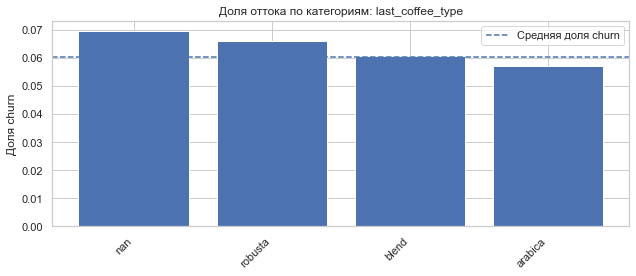


Признак: preferred_roast


,client_count,churn_rate
preferred_roast,,
medium,3458,0.061
light,3453,0.060
dark,3423,0.061
NaN,116,0.034


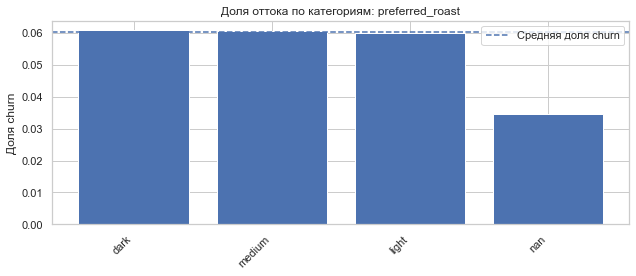


Признак: milk_preference


,client_count,churn_rate
milk_preference,,
whole,2876,0.062
oat,1982,0.060
almond,1483,0.065
skim,1451,0.059
none,1015,0.055
soy,975,0.056
NaN,668,0.060


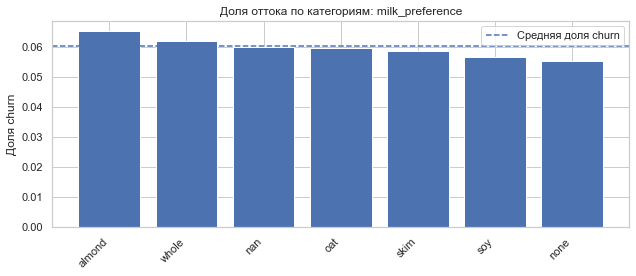


Признак: coffee_bean_origin


,client_count,churn_rate
coffee_bean_origin,,
ethiopia,1690,0.059
kenya,1646,0.054
vietnam,1635,0.056
guatemala,1621,0.062
brazil,1596,0.065
colombia,1580,0.064
NaN,682,0.063


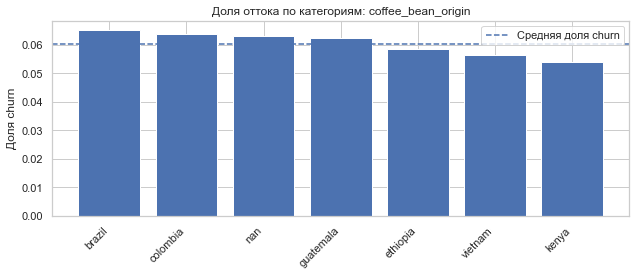


Признак: last_drink_size


,client_count,churn_rate
last_drink_size,,
medium,4925,0.058
large,2997,0.061
small,2024,0.058
NaN,504,0.083


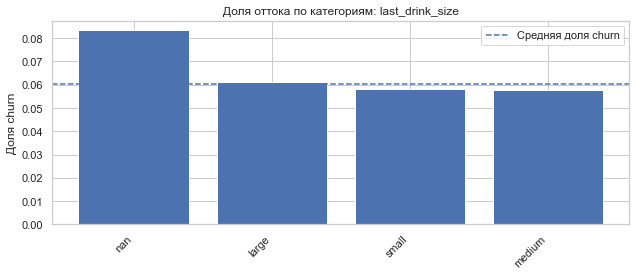


Признак: subscription_status


,client_count,churn_rate
subscription_status,,
none,3803,0.050
basic,2862,0.054
premium,1923,0.070
NaN,938,0.052
pro,924,0.108


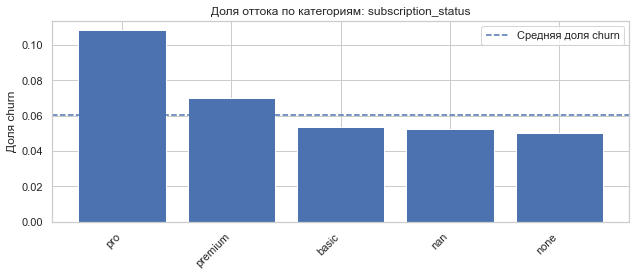


Признак: seasons


,client_count,churn_rate
seasons,,
spring,2507,0.063
autumn,2433,0.058
winter,2423,0.057
summer,2408,0.057
NaN,679,0.080


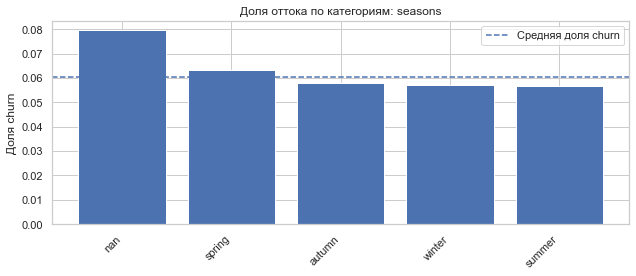


Признак: phone_type


,client_count,churn_rate
phone_type,,
android,4611,0.065
ios,4502,0.057
web,1001,0.058
NaN,336,0.036


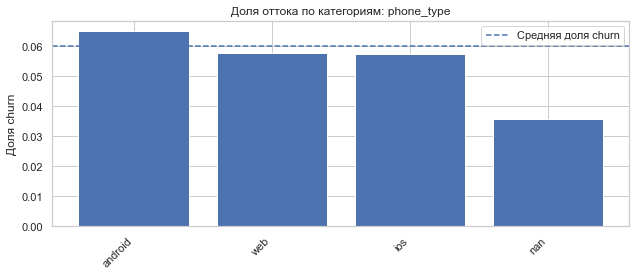


Признак: geo_location


,client_count,churn_rate
geo_location,,
geo_2,1629,0.072
geo_3,1573,0.055
geo_1,1532,0.052
geo_99,117,0.060
geo_95,110,0.091
NaN,110,0.064
geo_92,108,0.046
geo_93,98,0.102
geo_96,97,0.031


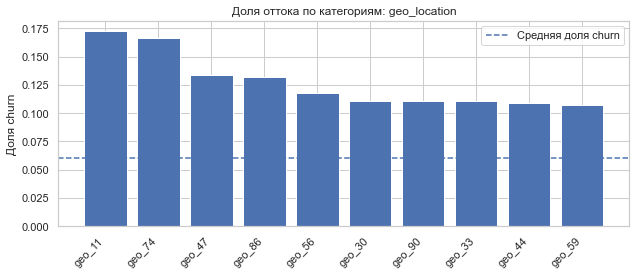

In [8]:
# Количество категорий и доля пропусков
categorical_summary = pd.DataFrame({
    'feature': categorical_features,
    'unique_categories': [data[col].nunique(dropna=True) for col in categorical_features],
    'missing_count': [data[col].isna().sum() for col in categorical_features],
}).sort_values('unique_categories')
display(categorical_summary)

for col in categorical_features:
    category_stats = (
        data.groupby(col, dropna=False)['churn']
        .agg(client_count='size', churn_rate='mean')
        .sort_values('client_count', ascending=False)
    )
    print(f'\nПризнак: {col}')
    display(category_stats.head(10))

    # Для региона визуализируем только наиболее многочисленные категории.
    category_stats = category_stats.sort_values('churn_rate', ascending=False)
    categories_to_plot = category_stats.head(10).index
    plot_stats = category_stats.loc[categories_to_plot].reset_index()
    plt.figure(figsize=(9, 4))
    plt.bar(plot_stats[col].astype(str), plot_stats['churn_rate'])
    plt.axhline(data['churn'].mean(), linestyle='--', label='Средняя доля churn')
    plt.title(f'Доля оттока по категориям: {col}')
    plt.ylabel('Доля churn')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

**Вывод по категориальным признакам.** Для моделирования необходимо кодировать признаки `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `seasons`, `phone_type` и `geo_location`, поскольку модель принимает числовой вход. Будет использован `OneHotEncoder(handle_unknown='ignore')`: он подходит для признаков с небольшим и умеренным числом категорий и безопасно обрабатывает категории, встретившиеся только в тестовых данных.

`geo_location` содержит 100 значений, однако объём данных и число категорий позволяют оставить его в One-Hot Encoding. Интерпретировать различия оттока по отдельным небольшим регионам нужно осторожно, так как оценки на малом числе клиентов нестабильны.

Категориальные признаки также позволяют генерировать дополнительные характеристики: например, признаки наличия подписки, использования мобильного канала вместо веб-версии или взаимодействия сезона и последнего типа напитка. На данном этапе удаляется только `user_id`; остальные категориальные признаки сохраняются как потенциально полезные.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично.


### 2.6. Анализ числовых признаков и выбросов

Проверим распределения числовых признаков и определим выбросы по Z-оценке. Значение считается выбросом, если его абсолютная Z-оценка превышает 3.

In [9]:
# Основные описательные статистики числовых признаков
display(data[numeric_features].describe().T)

# Сравнение медиан числовых признаков по классам
median_by_churn = data.groupby('churn')[numeric_features].median().T
median_by_churn.columns = ['not_churn_median', 'churn_median']
median_by_churn['difference'] = (
    median_by_churn['churn_median'] - median_by_churn['not_churn_median']
)
display(median_by_churn.sort_values('difference', key=abs, ascending=False))

,count,mean,std,min,25%,50%,75%,max
days_since_last_order,9505.000,4.394,4.859,0.000,1.000,3.000,6.000,40.000
order_frequency_month,9850.000,4.026,2.826,0.011,1.938,3.381,5.439,27.389
order_frequency_week,10062.000,0.931,0.657,-0.169,0.445,0.785,1.262,6.303
avg_order_value,9867.000,1063.741,707.713,-32.076,552.899,898.644,1406.332,5901.965
median_order_value,9619.000,452.651,258.658,-10.353,262.909,406.457,590.418,2189.102
total_spent_last_month,10156.000,1946.133,2370.620,-43.716,629.680,1300.410,2481.650,79298.850
total_spent_last_week,9506.000,413.005,445.635,-2290.559,136.566,288.277,549.699,8615.989
discount_usage_rate,10053.000,0.284,0.159,0.002,0.160,0.265,0.387,0.887
seasonal_menu_tried,9461.000,0.701,0.458,0.000,0.000,1.000,1.000,1.000
app_opens_per_week,9554.000,11.331,14.529,0.000,6.314,9.228,12.727,224.588


,not_churn_median,churn_median,difference
total_spent_last_month,1283.372,1518.289,234.918
total_spent_last_week,285.171,344.897,59.726
avg_order_value,899.580,885.566,-14.014
app_opens_per_week,9.091,11.781,2.689
app_crashes_last_month,1.000,3.000,2.000
days_since_last_promo,10.000,11.000,1.000
order_frequency_month,3.357,3.980,0.623
median_order_value,406.468,406.253,-0.215
order_frequency_week,0.777,0.917,0.140
review_rating_last_10,4.212,4.141,-0.071


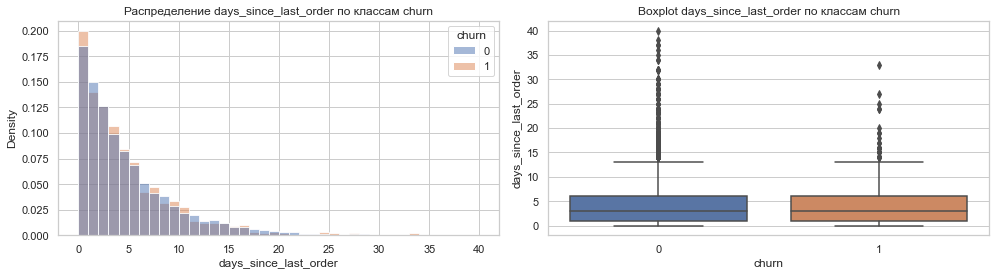

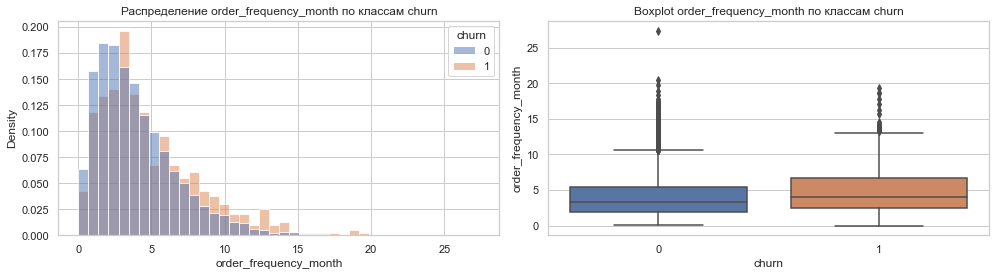

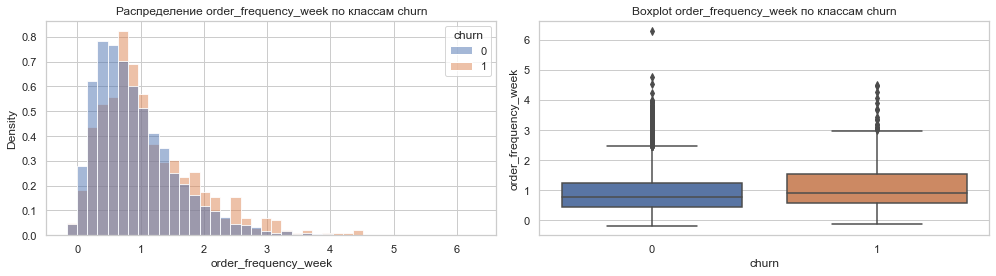

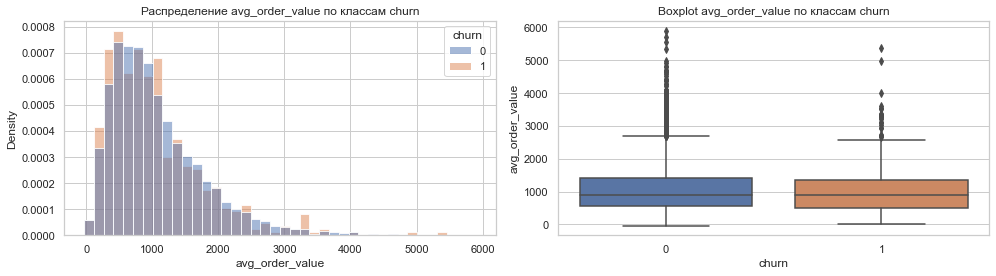

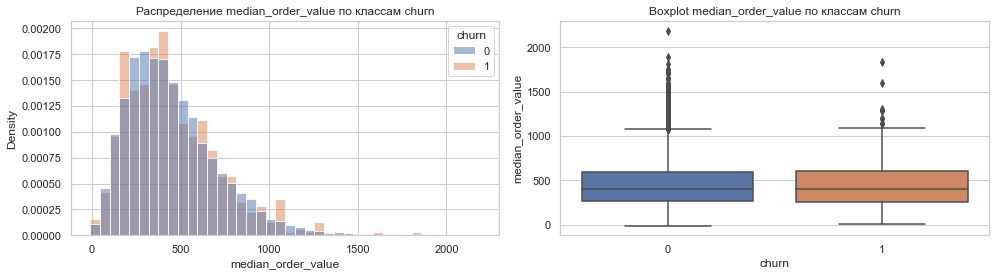

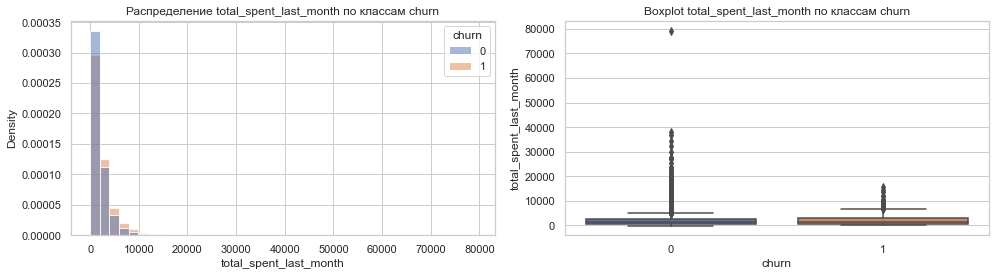

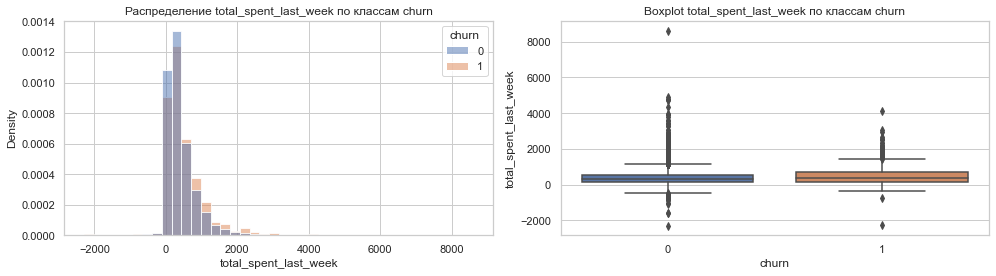

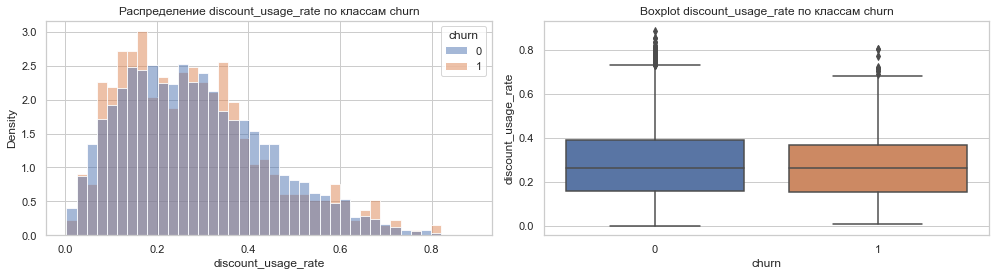

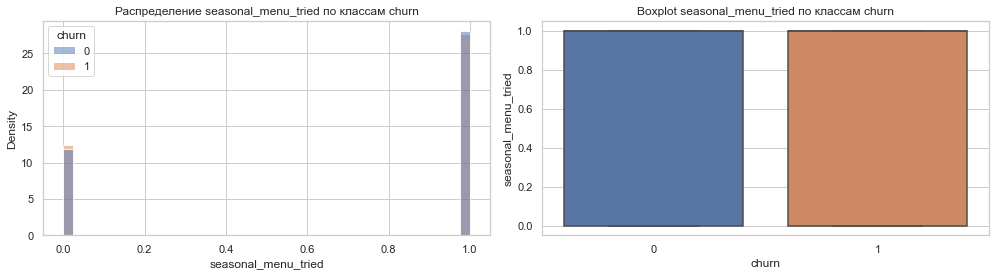

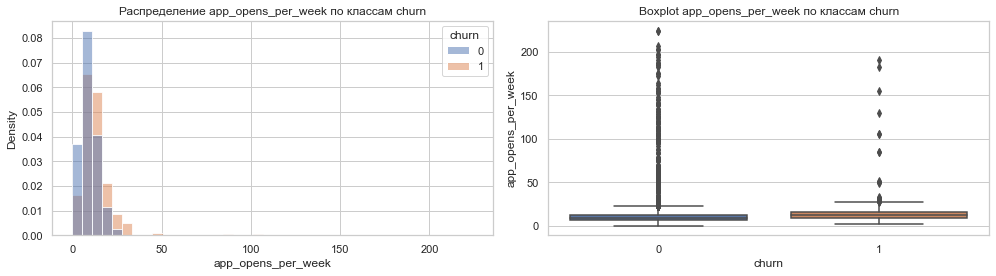

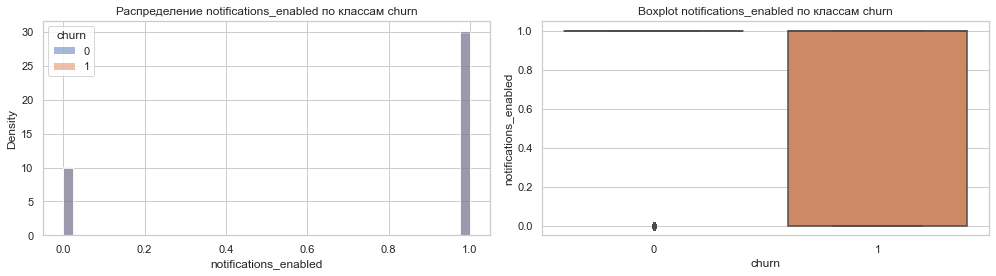

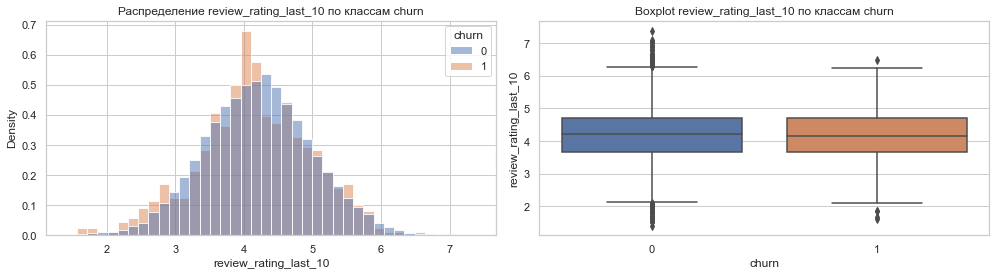

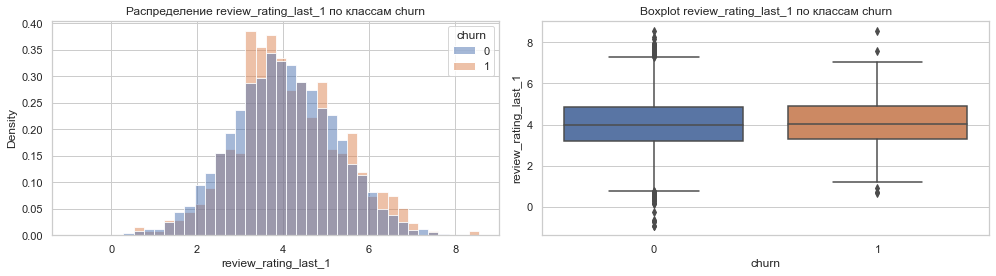

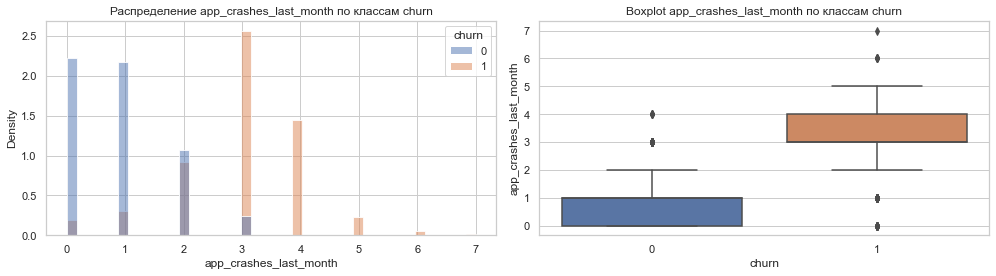

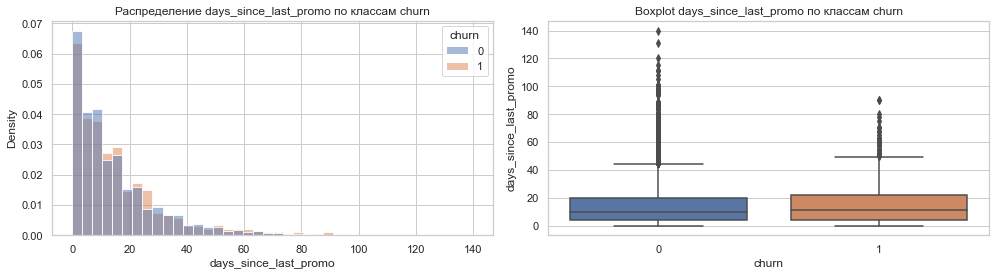

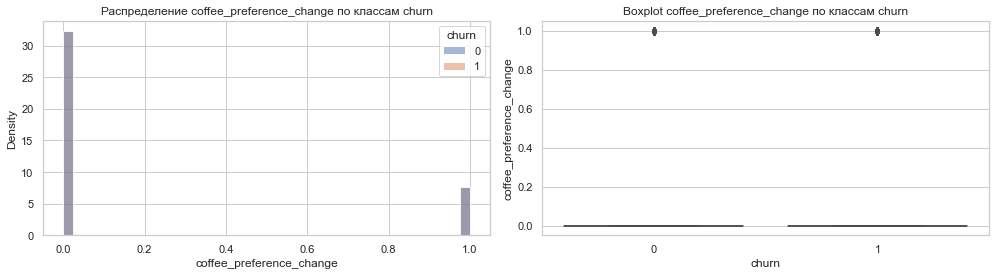

In [10]:
# Распределения числовых признаков
for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(data=data, x=col, hue='churn', bins=40, stat='density', common_norm=False, ax=axes[0])
    axes[0].set_title(f'Распределение {col} по классам churn')
    sns.boxplot(data=data, x='churn', y=col, ax=axes[1])
    axes[1].set_title(f'Boxplot {col} по классам churn')
    plt.tight_layout()
    plt.show()

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Рекомендую оставлять комментарии прямо под графиками, это улучшает читаемость проекта. Читать пояснения к выводам где-то далеко внизу в выводах не так удобно.

<br/>
<div class="alerфt alert-info"> На графиках видно, что у денежных признаков (`avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`), признаков активности (`app_opens_per_week`) и признаков давности (`days_since_last_order`, `days_since_last_promo`) есть правые хвосты: основная масса клиентов находится в умеренных значениях, а отдельные клиенты имеют существенно более высокие значения. Это похоже на естественную неоднородность клиентского поведения. При этом в части признаков обнаружены отрицательные значения, которые невозможны по смыслу для трат, частоты заказов и оценок. Такие строки будем считать ошибками формирования витрины и удалим до обучения модели.
</div>

,feature,median,outlier_count,outlier_share_from_non_missing
14,days_since_last_promo,10.000,195,0.020
0,days_since_last_order,3.000,186,0.020
6,total_spent_last_week,288.277,167,0.018
3,avg_order_value,898.644,150,0.015
5,total_spent_last_month,1300.410,148,0.015
1,order_frequency_month,3.381,134,0.014
9,app_opens_per_week,9.228,134,0.014
2,order_frequency_week,0.785,129,0.013
4,median_order_value,406.457,116,0.012
7,discount_usage_rate,0.265,42,0.004


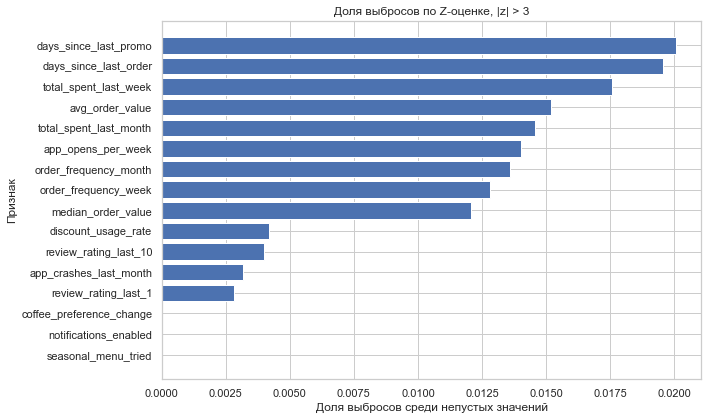

In [11]:
# Количество выбросов по Z-оценке без заполнения пропусков на этапе EDA
outlier_summary = []
for col in numeric_features:
    values = data[col].dropna()
    mean = values.mean()
    std = values.std()
    median = values.median()

    if std == 0:
        outlier_mask = pd.Series(False, index=values.index)
    else:
        z_scores = (values - mean) / std
        outlier_mask = z_scores.abs() > 3

    outlier_summary.append({
        'feature': col,
        'median': median,
        'outlier_count': int(outlier_mask.sum()),
        'outlier_share_from_non_missing': outlier_mask.mean(),
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values('outlier_count', ascending=False)
)
display(outlier_summary)

plot_outliers = outlier_summary.sort_values('outlier_share_from_non_missing')
plt.figure(figsize=(10, 6))
plt.barh(plot_outliers['feature'], plot_outliers['outlier_share_from_non_missing'])
plt.title('Доля выбросов по Z-оценке, |z| > 3')
plt.xlabel('Доля выбросов среди непустых значений')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

**Вывод по выбросам.** В числовых признаках присутствуют экстремальные значения. По правилу `|z| > 3` больше всего выбросов обнаруживается в `days_since_last_promo`, `days_since_last_order`, `total_spent_last_week`, `avg_order_value` и `total_spent_last_month`. Кроме того, в отдельных денежных и частотных признаках встречаются отрицательные значения, а в признаках оценок — значения за пределами ожидаемой шкалы; это может быть следствием ошибок или особенностей формирования аналитической витрины.

Удалять клиентов с экстремальными значениями не будем: при редком целевом классе это может сократить полезную информацию об оттоке. В числовой ветке пайплайна после заполнения пропусков будут вычисляться среднее, стандартное отклонение и медиана на обучающей части данных. Значения с `|z| > 3` будут заменяться медианой соответствующего признака. Медиана выбрана как устойчивая к крайним значениям замена.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
А с отрицательными значениям что будем делать?

<br/>
<div class="alerфt alert-info"> Некоторые числовые признаки по смыслу не могут быть отрицательными: частота заказов, сумма покупок, чек, оценка, число открытий приложения, число сбоев, доли и давность событий. Отрицательные значения в таких столбцах будем считать техническими ошибками аналитической витрины.

В отличие от реалистичных правых хвостов распределений, такие значения не несут бизнес-смысла: клиент не может сделать отрицательное число заказов или потратить отрицательную сумму. Поэтому строки с отрицательными значениями удалим до разбиения данных. Дополнительно удалим один наиболее выраженный выброс по числу заказов: клиент с максимальной месячной частотой заказов сильно оторван от основной массы наблюдений и может искажать линейную модель.
</div>

In [12]:
non_negative_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'seasonal_menu_tried',
    'app_opens_per_week',
    'notifications_enabled',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'coffee_preference_change',
]

negative_counts = (data[non_negative_cols] < 0).sum().sort_values(ascending=False)
negative_counts = negative_counts[negative_counts > 0]

display(negative_counts.to_frame('negative_count'))

negative_rows_mask = (data[non_negative_cols] < 0).any(axis=1)
print('Строк с хотя бы одним отрицательным значением:', negative_rows_mask.sum())
print('Доля таких строк:', f'{negative_rows_mask.mean():.2%}')
print('Распределение churn среди удаляемых строк:')
display(data.loc[negative_rows_mask, 'churn'].value_counts().sort_index().to_frame('count'))

# Удаляем строки с некорректными отрицательными значениями.
data = data.loc[~negative_rows_mask].copy()

# Один наиболее выраженный выброс по заказам: максимальная месячная частота заказов.
max_order_idx = data['order_frequency_month'].idxmax()
order_outlier = data.loc[[max_order_idx], [
    'user_id',
    'order_frequency_month',
    'order_frequency_week',
    'total_spent_last_month',
    'total_spent_last_week',
    'churn',
]]

print('Кандидат на удаление как явный выброс по заказам:')
display(order_outlier)

data = data.drop(index=max_order_idx).reset_index(drop=True)

print('Размер данных после удаления некорректных строк и одного явного выброса:', data.shape)
print('Новая доля churn:', f'{data[target_col].mean():.2%}')

,negative_count
total_spent_last_week,171
order_frequency_week,83
review_rating_last_1,6
avg_order_value,2
median_order_value,2
total_spent_last_month,2


Строк с хотя бы одним отрицательным значением: 188
Доля таких строк: 1.80%
Распределение churn среди удаляемых строк:


,count
0,177
1,11


Кандидат на удаление как явный выброс по заказам:


,user_id,order_frequency_month,order_frequency_week,total_spent_last_month,total_spent_last_week,churn
3207,user_06006,27.389,6.303,16091.752,3452.022,0


Размер данных после удаления некорректных строк и одного явного выброса: (10261, 27)
Новая доля churn: 6.02%


<br/>
<div class="alerфt alert-info"> Было найдено и удалено **188 строк** с отрицательными значениями в признаках, где отрицательные значения невозможны по смыслу. Среди них было 177 клиентов без оттока и 11 клиентов с оттоком, поэтому удаление почти не меняет баланс классов. Также удалён один экстремальный клиент с максимальной месячной частотой заказов. Остальные высокие значения в денежных признаках, активности приложения и давности событий оставляем: они выглядят как реалистичные правые хвосты клиентского поведения, а не как ошибки данных.
</div>

### 2.7. Корреляционный анализ

Для числовых признаков используем корреляцию Спирмена, поскольку часть признаков имеет асимметричные распределения и выбросы. Отдельно выделим пары признаков с высокой абсолютной корреляцией.

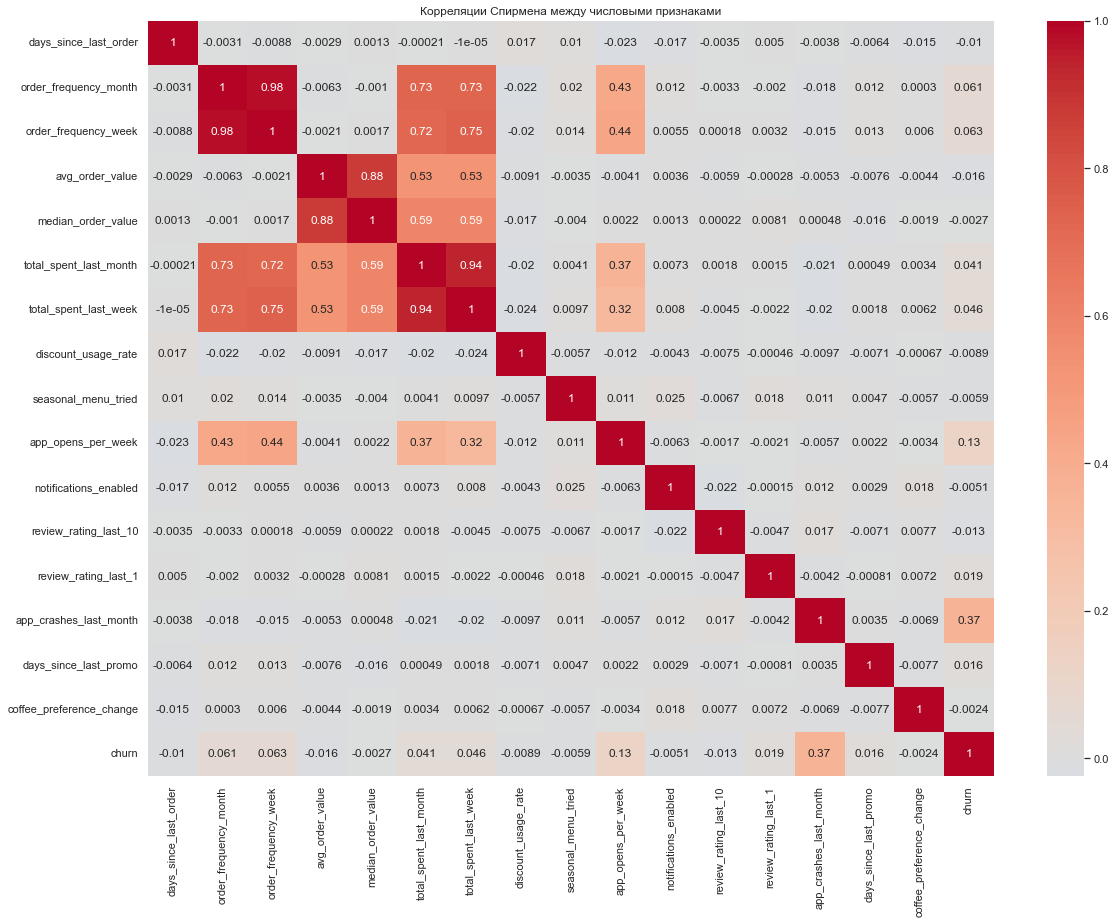

,spearman_corr_with_churn
app_crashes_last_month,0.365
app_opens_per_week,0.127
order_frequency_week,0.063
order_frequency_month,0.061
total_spent_last_week,0.046
total_spent_last_month,0.041
review_rating_last_1,0.019
avg_order_value,-0.016
days_since_last_promo,0.016
review_rating_last_10,-0.013


,feature_1,feature_2,spearman_corr
0,order_frequency_month,order_frequency_week,0.980
2,total_spent_last_month,total_spent_last_week,0.936
1,avg_order_value,median_order_value,0.879


In [13]:
corr = data[numeric_features + [target_col]].corr(method='spearman')

plt.figure(figsize=(17, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title('Корреляции Спирмена между числовыми признаками')
plt.tight_layout()
plt.show()

corr_with_target = (
    corr[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
    .to_frame('spearman_corr_with_churn')
)
display(corr_with_target)

high_corr_pairs = []
for i, feature_1 in enumerate(numeric_features):
    for feature_2 in numeric_features[i + 1:]:
        corr_value = corr.loc[feature_1, feature_2]
        if abs(corr_value) >= 0.8:
            high_corr_pairs.append({
                'feature_1': feature_1,
                'feature_2': feature_2,
                'spearman_corr': corr_value,
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values(
    'spearman_corr', key=abs, ascending=False
)
display(high_corr_pairs)

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Предлагаю добавить на график значения корреляций с помощью параметра annot=True. Без него график не так хорошо читаем. Значений не сильно много, добавление показателей на график только улучшит визуализацию.

<br/>
<div class="alerфt alert-info"> Спасибо)Добавил на график
</div>

**Вывод по корреляциям.** Выявлены три особенно тесно связанные пары признаков:

- `order_frequency_month` и `order_frequency_week`: корреляция Спирмена около **0,981**;
- `total_spent_last_month` и `total_spent_last_week`: около **0,918**;
- `avg_order_value` и `median_order_value`: около **0,880**.

Эти признаки описывают близкие стороны поведения клиента в разных временных масштабах или разными статистиками, поэтому при линейной модели могут приводить к мультиколлинеарности и затруднять интерпретацию отдельных коэффициентов. Однако они могут быть полезны для создания относительных признаков: недельная активность относительно месячной, недельные траты относительно месячных, отношение среднего чека к медианному. Поэтому на baseline-этапе признаки сохраняются, а в этапе feature engineering используются для генерации отношений и последующего сравнения качества модели. Автоматически удалять их до эксперимента нецелесообразно.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Абсолютно верный подход. Пока наблюдаем, а затем можем сделать некоторые преобразования, чтобы и полезную информацию из признака сохранить, и коллинеарности избежать.

### 2.8. Выводы по исследовательскому анализу данных

1. В аналитической витрине представлены 10 450 уникальных клиентов; дубликаты строк и идентификаторов отсутствуют.
2. Целевая переменная `churn` существенно несбалансирована: отток наблюдается только у 629 клиентов, или 6,02% выборки. Для оценки модели основной метрикой выбирается `PR-AUC`, а разбиения выполняются со стратификацией.
3. `user_id` является техническим идентификатором и исключается из признаков модели. Другие признаки описывают поведение, траты, предпочтения и взаимодействие пользователя с сервисом и сохраняются для дальнейших экспериментов.
4. Пропуски распространены по многим признакам. Удаление неполных строк привело бы к потере около 78,19% данных, поэтому числовые пропуски будут заполнены медианой, а категориальные — наиболее частым значением внутри пайплайна.
5. Категориальные признаки будут закодированы с помощью `OneHotEncoder`, поскольку логистическая регрессия не работает со строковыми значениями напрямую. `geo_location` оставляется, несмотря на 100 категорий, так как он может отражать региональные особенности поведения.
6. В числовых признаках присутствуют выбросы и отдельные аномальные значения. Для сохранения клиентов в выборке выбросы будут определяться по правилу `|z| > 3` и заменяться медианой признака внутри пайплайна.
7. Обнаружена высокая корреляция между месячной и недельной частотой заказов, месячными и недельными тратами, средним и медианным чеком. Эти признаки не удаляются автоматически: сначала на их основе будут созданы относительные характеристики, после чего полезность подхода будет проверена по кросс-валидации.
8. По результатам EDA сформированы решения для следующего этапа: исключить `user_id`, использовать комбинированный пайплайн предобработки, учесть дисбаланс классов и протестировать feature engineering на основе поведения и трат клиентов.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отличное исследование и выводы. Единственное, нужно добавить пояснение, что делаем с отрицательными значениями.
    
Я бы их удалил еще на этапе исследования данных. Также обрати внимание, у нас есть один значительный выброс по заказам. Остальные данные выглядят реалистичными, их можно не обрабатывать.

<br/>
<div class="alerфt alert-info"> ### 2.8. Выводы по исследовательскому анализу данных

1. В аналитической витрине представлены 10 450 уникальных клиентов; дубликаты строк и идентификаторов отсутствуют.
2. Целевая переменная `churn` существенно несбалансирована: отток наблюдается только у 629 клиентов, или 6,02% исходной выборки. Для оценки модели основной метрикой выбирается `PR-AUC`, а разбиения выполняются со стратификацией.
3. `user_id` является техническим идентификатором и исключается из признаков модели. Другие признаки описывают поведение, траты, предпочтения и взаимодействие пользователя с сервисом и сохраняются для дальнейших экспериментов.
4. Пропуски распространены по многим признакам. Удаление неполных строк привело бы к потере около 78% данных, поэтому числовые пропуски будут заполнены медианой, а категориальные — наиболее частым значением внутри пайплайна.
5. Категориальные признаки будут закодированы с помощью `OneHotEncoder`. `geo_location` оставляется, несмотря на 100 категорий, так как может отражать региональные особенности поведения.
6. Отрицательные значения в признаках, где они невозможны по смыслу, удалены как ошибки данных. Также удалён один явно выраженный выброс по частоте заказов. Остальные правые хвосты оставлены как потенциально полезное клиентское поведение, а не автоматически заменены медианами.
7. Обнаружена высокая корреляция между месячной и недельной частотой заказов, месячными и недельными тратами, средним и медианным чеком. Эти признаки не удаляются автоматически: на их основе будут созданы относительные характеристики и затем проверены по кросс-валидации.
8. По результатам EDA сформированы решения для следующего этапа: исключить `user_id`, удалить некорректные отрицательные значения, использовать пайплайн предобработки, учесть дисбаланс классов и протестировать feature engineering на основе активности, трат, оценок и взаимодействия с приложением.
</div>

## Этап 3. Предобработка данных

Разделим данные на обучающую и тестовую выборки в пропорции 80/20. Из-за дисбаланса классов используем стратификацию по `churn`. Предобработка будет оформлена в виде пайплайна, чтобы избежать утечки данных и обеспечить воспроизводимость.

In [14]:
X = data.drop(columns=[target_col, id_col])
y = data[target_col]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Размер train_val:', X_train_val.shape)
print('Размер test:', X_test.shape)
print('Доля churn в train_val:', y_train_val.mean())
print('Доля churn в test:', y_test.mean())

Размер train_val: (8208, 25)
Размер test: (2053, 25)
Доля churn в train_val: 0.06018518518518518
Доля churn в test: 0.06039941548952752



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Замечательно, соотношение классов одинаковое.

In [15]:
class ZScoreClipper(BaseEstimator, TransformerMixin):
    """Заменяет выбросы в числовых признаках на медианы по Z-оценке.

    Выбросом считается значение, для которого |z| > threshold.
    Все статистики рассчитываются только на обучающей части данных.
    """
    def __init__(self, threshold=3):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.mean_ = X.mean()
        self.std_ = X.std().replace(0, np.nan)
        self.median_ = X.median()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        z_scores = (X - self.mean_) / self.std_
        outlier_mask = z_scores.abs() > self.threshold

        for col in X.columns:
            X.loc[outlier_mask[col], col] = self.median_[col]

        return X


def make_one_hot_encoder():
    """Создаёт OneHotEncoder с учётом разных версий scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def make_preprocessor(num_cols, cat_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('outlier_replacer', ZScoreClipper(threshold=3)),
        ('scaler', StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', make_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols),
        ],
        remainder='drop',
    )


base_numeric_features = X_train_val.select_dtypes(include='number').columns.tolist()
base_categorical_features = X_train_val.select_dtypes(exclude='number').columns.tolist()

base_preprocessor = make_preprocessor(base_numeric_features, base_categorical_features)

print('Числовых признаков:', len(base_numeric_features))
print('Категориальных признаков:', len(base_categorical_features))

Числовых признаков: 16
Категориальных признаков: 9


**Вывод по предобработке.** В пайплайн включены все решения, принятые на этапе EDA: числовые пропуски заменяются медианой, категориальные — наиболее частым значением; числовые выбросы определяются по Z-оценке (`|z| > 3`) и заменяются медианой; затем числовые признаки масштабируются, а категориальные кодируются методом One-Hot Encoding. Все статистики рассчитываются только на обучающей части данных, включая каждый обучающий фолд при кросс-валидации.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 

## Этап 4. Обучение и оценка базовой модели

В качестве точки отсчёта обучим две модели:

1. `DummyClassifier` — наивная baseline-модель, которая показывает минимальный уровень качества.
2. `LogisticRegression` — простая интерпретируемая модель, подходящая для табличных данных после кодирования и масштабирования.

Основная метрика для выбора модели — `PR-AUC`, потому что положительный класс редкий и нам важно качество ранжирования именно клиентов с оттоком.

In [16]:
def summarize_cv_results(cv_result, model_name):
    """Преобразует результат cross_validate в компактную таблицу."""
    row = {'model': model_name}
    for metric_name, values in cv_result.items():
        if metric_name.startswith('test_'):
            clean_name = metric_name.replace('test_', '')
            if clean_name == 'neg_log_loss':
                row['log_loss'] = -values.mean()
                row['log_loss_std'] = values.std()
            else:
                row[clean_name] = values.mean()
                row[f'{clean_name}_std'] = values.std()
    return row

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'neg_log_loss': 'neg_log_loss',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

baseline_models = {
    'dummy_prior': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'baseline_logreg': Pipeline(steps=[
        ('preprocessor', base_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='liblinear',
            random_state=RANDOM_STATE,
        )),
    ]),
}

cv_rows = []
for model_name, model in baseline_models.items():
    cv_result = cross_validate(
        model,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    cv_rows.append(summarize_cv_results(cv_result, model_name))

baseline_cv_results = pd.DataFrame(cv_rows).sort_values('pr_auc', ascending=False)
display(baseline_cv_results)

,model,roc_auc,roc_auc_std,pr_auc,pr_auc_std,log_loss,log_loss_std,precision,precision_std,recall,recall_std,f1,f1_std
1,baseline_logreg,0.784,0.024,0.304,0.020,0.493,0.007,0.156,0.005,0.648,0.043,0.251,0.010
0,dummy_prior,0.500,0.000,0.060,0.000,2.079,0.006,0.000,0.000,0.000,0.000,0.000,0.000


**Вывод по baseline.** `DummyClassifier` нужен только как нижняя граница качества: он не находит клиентов с оттоком. Логистическая регрессия существенно лучше по `PR-AUC`, `ROC-AUC`, `Recall` и `F1`, значит признаки действительно содержат информацию об оттоке. При этом задача остаётся сложной: из-за дисбаланса классов precision для класса 1 ниже recall, то есть модель находит большую часть уходящих клиентов, но также даёт заметное число ложных срабатываний.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все верно по этой части.

##  Создание, проверка и отбор новых признаков

На этапе EDA были выявлены признаки, которые описывают близкие стороны поведения клиента: недельная и месячная частота заказов, недельные и месячные траты, средний и медианный чек. Поэтому новые признаки будут строиться не случайно, а на основе бизнес-логики и результатов анализа:

- относительная недельная активность по сравнению с месячной;
- относительные недельные траты по сравнению с месячными;
- соотношение среднего и медианного чека;
- изменение последней оценки относительно средней оценки последних заказов;
- признаки давности заказа и промо;
- признаки пользовательского опыта в приложении.

Также добавим математические преобразования:

- `sqrt` — сглаживает влияние больших значений и помогает модели мягче учитывать признаки с длинными хвостами;
- `square` — усиливает влияние больших значений, например большой давности заказа или большого числа сбоев приложения.

После генерации признаков нужно сравнить качество модели с новыми признаками и без них по кросс-валидации. Затем коэффициенты логистической регрессии будут использованы для отбора наиболее значимых признаков.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Здесь я бы очень рекомендовал не абстрактно описать, что где-то будем возводить в квадрат, а где-то брать корень, вместо этого лучше прямо проговорить, в каких случаях и почему будем применять преобразования.

<br/>
<div class="alerфt alert-info"> 
Добавляю более конкретные шаги по новым признакам
</div>

<br/>
<div class="alerфt alert-info"> 
На этом этапе новые признаки сначала создаются как **кандидаты**. Это означает, что они не считаются автоматически полезными. После создания мы проверим их вклад в модель по нескольким критериям:

1. сравним качество модели с новыми признаками и baseline-модели;
2. интерпретируем коэффициенты логистической регрессии;
3. после интерпретации коэффициентов проведём корреляционный анализ новых признаков;
4. проверим, не появились ли пары новых признаков с высокой корреляцией;
5. удалим слабые признаки, если они почти не влияют на модель или дублируют другие признаки.

---

**1. Отношения недельных и месячных показателей**

В данных есть пары признаков, которые описывают похожие аспекты поведения клиента за разные периоды:

- `total_spent_last_week` и `total_spent_last_month`;
- `order_frequency_week` и `order_frequency_month`.

На основе этих признаков создаются отношения:

- `spent_week_to_month_ratio`;
- `orders_week_to_month_ratio`.

Эти признаки проверяют гипотезу о том, что для оттока важны не только абсолютные траты или частота заказов, но и **изменение активности в последнюю неделю относительно месячного уровня**.

---

**2. Разность и отношение среднего и медианного чека**

В данных есть два близких признака:

- `avg_order_value`;
- `median_order_value`.

Оба описывают размер заказа, но делают это по-разному. Средний чек чувствителен к редким крупным заказам, а медианный чек лучше отражает типичный размер заказа клиента.

На их основе создаются признаки:

- `avg_to_median_order_ratio`;
- `order_value_gap`.

Эти признаки проверяют гипотезу о **нестабильности размера заказов**. Если средний чек сильно отличается от медианного, значит у клиента были нетипичные заказы. Такое поведение может быть связано с изменением привычек или нерегулярностью покупок.

После обучения модели нужно проверить, появились ли эти признаки среди значимых по модулю коэффициента. Если коэффициенты малы, такие признаки можно считать слабыми и удалить.

---

**3. Изменение последней оценки относительно среднего уровня**

Для оценки клиентского опыта есть признаки:

- `review_rating_last_10`;
- `review_rating_last_1`.

На их основе создаётся признак:

- `rating_drop_last_order`.

Он рассчитывается как разность между средней оценкой последних заказов и оценкой последнего заказа.

Этот признак проверяет гипотезу о том, что отток может быть связан не только с общим уровнем удовлетворённости, но и с **ухудшением последнего клиентского опыта**.

---

**4. Давность промо относительно давности заказа**

В данных есть признаки:

- `days_since_last_promo`;
- `days_since_last_order`.

На их основе создаётся признак:

- `promo_order_recency_gap`.

Он показывает, насколько давно клиент использовал промо относительно последнего заказа.

---

**5. Квадратный корень для признаков с широким диапазоном значений**

Для части числовых признаков характерны широкие диапазоны и правые хвосты распределений:

- `days_since_last_order`;
- `days_since_last_promo`;
- `total_spent_last_month`;
- `total_spent_last_week`;
- `avg_order_value`;
- `median_order_value`;
- `app_opens_per_week`;
- `app_crashes_last_month`.

Для них создаются `sqrt`-признаки:

- `sqrt_days_since_last_order`;
- `sqrt_days_since_last_promo`;
- `sqrt_total_spent_last_month`;
- `sqrt_total_spent_last_week`;
- `sqrt_avg_order_value`;
- `sqrt_median_order_value`;
- `sqrt_app_opens_per_week`;
- `sqrt_app_crashes_last_month`.

Квадратный корень сглаживает большие значения и снижает влияние экстремальных наблюдений, но при этом сохраняет порядок значений. Это мягкая альтернатива логарифмированию, которое в этом проекте не используется.

---

**6. Квадратичные признаки**

Для некоторых признаков связь с оттоком может быть не линейной, а U-образной или перевёрнутой U-образной. Поэтому добавляются квадратичные признаки:

- `days_since_last_order_sq`;
- `days_since_last_promo_sq`;
- `app_crashes_last_month_sq`;
- `discount_usage_rate_sq`;
- `rating_drop_last_order_sq`.

Квадрат признака помогает логистической регрессии учитывать нелинейность.

---

**7. Взаимодействия признаков**

Некоторые эффекты могут проявляться не по отдельности, а совместно. Поэтому добавляются признаки взаимодействия:

- `recency_app_activity_interaction`;
- `discount_frequency_interaction`;
- `crashes_app_opens_interaction`;
- `recency_rating_interaction`.

Они проверяют следующие гипотезы:

- давность заказа может иметь разный смысл при разной активности в приложении;
- доля скидок может быть важнее с учётом частоты заказов;
- сбои приложения могут сильнее влиять на клиентов, которые часто открывают приложение;
- давность заказа может быть связана с последней оценкой клиента.

---

**Как будем решать, какие признаки оставить**

После создания признаков-кандидатов решение будет приниматься не вручную «на глаз», а по нескольким проверкам.

Оставляем признаки, если они:

- улучшают качество модели по `PR-AUC`;
- имеют заметный модуль коэффициента логистической регрессии;
- имеют понятную бизнес-интерпретацию;
- не являются явно слабым дублем другого признака.

Кандидаты на удаление:

- признаки с очень маленьким модулем коэффициента;
- признаки с низкой корреляцией с `churn`;
- признаки, которые сильно коррелируют с другими новыми признаками и при этом слабее по коэффициенту;
- признаки, удаление которых не ухудшает `PR-AUC` на кросс-валидации.

</div>

In [17]:
class CandidateFeatureEngineer(BaseEstimator, TransformerMixin):
    """Генерация расширенного набора новых признаков-кандидатов.

    На этом шаге признаки ещё не считаются финальными. Сначала создаём расширенный
    набор, затем проверяем его на данных: через качество модели, коэффициенты и корреляции.

    Логарифмирование и биннинг не используются.
    """

    def __init__(self):
        self.eps = 1e-6

    def fit(self, X, y=None):
        return self

    def _safe_divide(self, numerator, denominator):
        """Безопасное деление с защитой от деления на ноль."""
        result = numerator / (denominator + self.eps)
        return result.replace([np.inf, -np.inf], np.nan)

    def _non_negative(self, series):
        """Ограничивает значения снизу нулём для sqrt-преобразований."""
        return np.clip(series, a_min=0, a_max=None)

    def transform(self, X):
        X = X.copy()

        for col in X.select_dtypes(include='number').columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')

        # 1. Отношения недельных и месячных показателей.
        X['spent_week_to_month_ratio'] = self._safe_divide(
            X['total_spent_last_week'],
            X['total_spent_last_month']
        )
        X['orders_week_to_month_ratio'] = self._safe_divide(
            X['order_frequency_week'],
            X['order_frequency_month']
        )

        # 2. Соотношение и разность среднего и медианного чека.
        X['avg_to_median_order_ratio'] = self._safe_divide(
            X['avg_order_value'],
            X['median_order_value']
        )
        X['order_value_gap'] = X['avg_order_value'] - X['median_order_value']

        # 3. Средние месячные траты на один заказ.
        X['monthly_spent_per_order'] = self._safe_divide(
            X['total_spent_last_month'],
            X['order_frequency_month']
        )

        # 4. Изменение последней оценки относительно средней оценки последних заказов.
        X['rating_drop_last_order'] = (
            X['review_rating_last_10'] - X['review_rating_last_1']
        )

        # 5. Разрыв между давностью промо и давностью заказа.
        X['promo_order_recency_gap'] = (
            X['days_since_last_promo'] - X['days_since_last_order']
        )

        # 6. sqrt-признаки: сглаживание больших значений без логарифма.
        sqrt_cols = [
            'days_since_last_order',
            'days_since_last_promo',
            'total_spent_last_month',
            'total_spent_last_week',
            'avg_order_value',
            'median_order_value',
            'app_opens_per_week',
            'app_crashes_last_month',
        ]

        for col in sqrt_cols:
            X[f'sqrt_{col}'] = np.sqrt(self._non_negative(X[col]))

        # 7. Квадраты: проверка нелинейных, U-образных или перевёрнутых U-образных зависимостей.
        square_cols = [
            'days_since_last_order',
            'days_since_last_promo',
            'app_crashes_last_month',
            'discount_usage_rate',
            'rating_drop_last_order',
        ]

        for col in square_cols:
            X[f'{col}_sq'] = X[col] ** 2

        # 8. Взаимодействия: проверка совместного эффекта признаков.
        X['recency_app_activity_interaction'] = (
            X['days_since_last_order'] * X['app_opens_per_week']
        )
        X['discount_frequency_interaction'] = (
            X['discount_usage_rate'] * X['order_frequency_month']
        )
        X['crashes_app_opens_interaction'] = (
            X['app_crashes_last_month'] * X['app_opens_per_week']
        )
        X['recency_rating_interaction'] = (
            X['days_since_last_order'] * X['review_rating_last_1']
        )

        return X


candidate_feature_engineer = CandidateFeatureEngineer()

X_train_val_candidate_preview = candidate_feature_engineer.fit_transform(X_train_val)

candidate_new_features = [
    col for col in X_train_val_candidate_preview.columns
    if col not in X_train_val.columns
]

print('Количество новых признаков-кандидатов:', len(candidate_new_features))
print('Новые признаки-кандидаты:')
display(candidate_new_features)

candidate_numeric_features = (
    X_train_val_candidate_preview
    .select_dtypes(include='number')
    .columns
    .tolist()
)

candidate_categorical_features = (
    X_train_val_candidate_preview
    .select_dtypes(exclude='number')
    .columns
    .tolist()
)

print('Числовых признаков после генерации кандидатов:', len(candidate_numeric_features))
print('Категориальных признаков после генерации кандидатов:', len(candidate_categorical_features))

Количество новых признаков-кандидатов: 24
Новые признаки-кандидаты:


['spent_week_to_month_ratio',
 'orders_week_to_month_ratio',
 'avg_to_median_order_ratio',
 'order_value_gap',
 'monthly_spent_per_order',
 'rating_drop_last_order',
 'promo_order_recency_gap',
 'sqrt_days_since_last_order',
 'sqrt_days_since_last_promo',
 'sqrt_total_spent_last_month',
 'sqrt_total_spent_last_week',
 'sqrt_avg_order_value',
 'sqrt_median_order_value',
 'sqrt_app_opens_per_week',
 'sqrt_app_crashes_last_month',
 'days_since_last_order_sq',
 'days_since_last_promo_sq',
 'app_crashes_last_month_sq',
 'discount_usage_rate_sq',
 'rating_drop_last_order_sq',
 'recency_app_activity_interaction',
 'discount_frequency_interaction',
 'crashes_app_opens_interaction',
 'recency_rating_interaction']

Числовых признаков после генерации кандидатов: 40
Категориальных признаков после генерации кандидатов: 9


**Проверка качества модели со всеми новыми признаками-кандидатами**

Сначала проверим, помогают ли новые признаки в целом. Для этого сравним baseline-модель и модель со всеми признаками-кандидатами по кросс-валидации.

In [18]:

candidate_preprocessor = make_preprocessor(
    candidate_numeric_features,
    candidate_categorical_features
)

candidate_logreg = Pipeline(steps=[
    ('feature_engineer', CandidateFeatureEngineer()),
    ('preprocessor', candidate_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
    )),
])

candidate_cv_result = cross_validate(
    candidate_logreg,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

candidate_row = summarize_cv_results(
    candidate_cv_result,
    'candidate_engineered_logreg'
)

baseline_logreg_row = baseline_cv_results.query("model == 'baseline_logreg'").iloc[0]

candidate_comparison = pd.concat([
    baseline_cv_results,
    pd.DataFrame([candidate_row]),
], ignore_index=True).sort_values('pr_auc', ascending=False)

display(candidate_comparison)

candidate_delta = candidate_row['pr_auc'] - baseline_logreg_row['pr_auc']

print(f"PR-AUC baseline_logreg: {baseline_logreg_row['pr_auc']:.3f}")
print(f"PR-AUC candidate_engineered_logreg: {candidate_row['pr_auc']:.3f}")
print(f"Прирост PR-AUC после добавления всех новых признаков: {candidate_delta:.3f}")

,model,roc_auc,roc_auc_std,pr_auc,pr_auc_std,log_loss,log_loss_std,precision,precision_std,recall,recall_std,f1,f1_std
2,candidate_engineered_logreg,0.934,0.010,0.658,0.014,0.264,0.007,0.363,0.005,0.830,0.009,0.505,0.004
0,baseline_logreg,0.784,0.024,0.304,0.020,0.493,0.007,0.156,0.005,0.648,0.043,0.251,0.010
1,dummy_prior,0.500,0.000,0.060,0.000,2.079,0.006,0.000,0.000,0.000,0.000,0.000,0.000


PR-AUC baseline_logreg: 0.304
PR-AUC candidate_engineered_logreg: 0.658
Прирост PR-AUC после добавления всех новых признаков: 0.354


**Конкретный результат на данных проекта.**

После очистки данных baseline-логистическая регрессия показала `PR-AUC = 0.304`. Модель со всеми новыми признаками-кандидатами показала `PR-AUC = 0.658`. Прирост составил `+0.354`.

Это означает, что feature engineering дал основной прирост качества. Но это ещё не значит, что все новые признаки полезны: часть из них может быть слабой или дублировать другие признаки. Поэтому дальше анализируем коэффициенты и корреляции.

###  Интерпретация коэффициентов модели с новыми признаками

Теперь обучим модель со всеми признаками-кандидатами и посмотрим коэффициенты логистической регрессии. Так как числовые признаки масштабируются, модуль коэффициента можно использовать как ориентировочную меру важности.

Топ-30 признаков после добавления новых признаков:


,feature,coefficient,abs_coefficient,source_feature,feature_group
13,app_crashes_last_month,-6.395,6.395,app_crashes_last_month,исходный признак
30,sqrt_app_crashes_last_month,4.471,4.471,sqrt_app_crashes_last_month,sqrt-преобразование
33,app_crashes_last_month_sq,4.012,4.012,app_crashes_last_month_sq,квадратичный признак
99,geo_location_geo_33,2.438,2.438,geo_location,исходный признак
144,geo_location_geo_74,2.384,2.384,geo_location,исходный признак
97,geo_location_geo_31,2.203,2.203,geo_location,исходный признак
147,geo_location_geo_77,2.039,2.039,geo_location,исходный признак
124,geo_location_geo_56,1.919,1.919,geo_location,исходный признак
130,geo_location_geo_61,1.762,1.762,geo_location,исходный признак
127,geo_location_geo_59,1.703,1.703,geo_location,исходный признак


Новые признаки по важности коэффициентов:


,source_feature,feature_group,max_abs_coefficient,mean_abs_coefficient,coefficient,encoded_features_count
16,sqrt_app_crashes_last_month,sqrt-преобразование,4.471,4.471,4.471,1
0,app_crashes_last_month_sq,квадратичный признак,4.012,4.012,4.012,1
17,sqrt_app_opens_per_week,sqrt-преобразование,0.912,0.912,0.912,1
3,days_since_last_order_sq,квадратичный признак,0.637,0.637,-0.637,1
8,order_value_gap,разность,0.461,0.461,-0.461,1
21,sqrt_median_order_value,sqrt-преобразование,0.425,0.425,0.425,1
13,recency_app_activity_interaction,взаимодействие,0.410,0.410,-0.410,1
19,sqrt_days_since_last_order,sqrt-преобразование,0.409,0.409,-0.409,1
22,sqrt_total_spent_last_month,sqrt-преобразование,0.380,0.380,-0.380,1
6,discount_usage_rate_sq,квадратичный признак,0.369,0.369,-0.369,1


Топ-10 новых признаков:


,source_feature,feature_group,max_abs_coefficient,mean_abs_coefficient,coefficient,encoded_features_count
16,sqrt_app_crashes_last_month,sqrt-преобразование,4.471,4.471,4.471,1
0,app_crashes_last_month_sq,квадратичный признак,4.012,4.012,4.012,1
17,sqrt_app_opens_per_week,sqrt-преобразование,0.912,0.912,0.912,1
3,days_since_last_order_sq,квадратичный признак,0.637,0.637,-0.637,1
8,order_value_gap,разность,0.461,0.461,-0.461,1
21,sqrt_median_order_value,sqrt-преобразование,0.425,0.425,0.425,1
13,recency_app_activity_interaction,взаимодействие,0.410,0.410,-0.410,1
19,sqrt_days_since_last_order,sqrt-преобразование,0.409,0.409,-0.409,1
22,sqrt_total_spent_last_month,sqrt-преобразование,0.380,0.380,-0.380,1
6,discount_usage_rate_sq,квадратичный признак,0.369,0.369,-0.369,1


Самые слабые новые признаки:


,source_feature,feature_group,max_abs_coefficient,mean_abs_coefficient,coefficient,encoded_features_count
1,avg_to_median_order_ratio,отношение,0.115,0.115,0.115,1
11,rating_drop_last_order,разность,0.115,0.115,0.115,1
12,rating_drop_last_order_sq,квадратичный признак,0.061,0.061,-0.061,1
5,discount_frequency_interaction,взаимодействие,0.048,0.048,-0.048,1
7,monthly_spent_per_order,отношение,0.039,0.039,0.039,1
23,sqrt_total_spent_last_week,sqrt-преобразование,0.032,0.032,0.032,1
4,days_since_last_promo_sq,квадратичный признак,0.023,0.023,-0.023,1
14,recency_rating_interaction,взаимодействие,0.022,0.022,0.022,1
9,orders_week_to_month_ratio,отношение,0.014,0.014,-0.014,1
15,spent_week_to_month_ratio,отношение,0.001,0.001,0.001,1


Средняя важность по группам преобразований:


,feature_group,features_count,max_abs_coefficient,mean_abs_coefficient
2,квадратичный признак,5,4.012,1.020
0,sqrt-преобразование,8,4.471,0.876
4,разность,3,0.461,0.273
1,взаимодействие,4,0.410,0.183
3,отношение,4,0.115,0.042


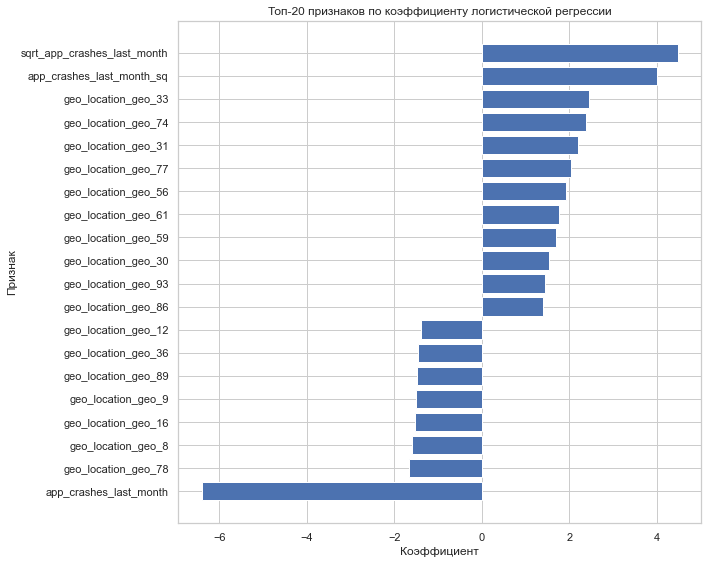

In [19]:

def get_logreg_feature_names(fitted_pipeline):
    """Возвращает имена признаков после FeatureEngineer и ColumnTransformer."""
    preprocessor = fitted_pipeline.named_steps['preprocessor']

    num_feature_names = list(preprocessor.transformers_[0][2])
    cat_input_features = list(preprocessor.transformers_[1][2])
    encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']

    try:
        encoded_cat_feature_names = encoder.get_feature_names_out(cat_input_features)
    except AttributeError:
        encoded_cat_feature_names = encoder.get_feature_names(cat_input_features)

    return np.array(num_feature_names + list(encoded_cat_feature_names))


def get_source_feature_name(encoded_feature, numeric_features, categorical_features):
    """Определяет исходный признак для признака после предобработки."""
    if encoded_feature in numeric_features:
        return encoded_feature

    for cat_feature in categorical_features:
        if encoded_feature.startswith(cat_feature + '_'):
            return cat_feature

    return encoded_feature


def define_feature_group(feature_name):
    """Определяет группу нового признака по названию."""
    if feature_name.startswith('sqrt_'):
        return 'sqrt-преобразование'
    if feature_name.endswith('_sq'):
        return 'квадратичный признак'
    if feature_name.endswith('_interaction'):
        return 'взаимодействие'
    if 'ratio' in feature_name or 'per_order' in feature_name:
        return 'отношение'
    if 'gap' in feature_name or 'drop' in feature_name:
        return 'разность'
    return 'исходный признак'


candidate_logreg.fit(X_train_val, y_train_val)

feature_names = get_logreg_feature_names(candidate_logreg)
coefficients = candidate_logreg.named_steps['classifier'].coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients),
}).sort_values('abs_coefficient', ascending=False)

coef_table['source_feature'] = coef_table['feature'].apply(
    lambda x: get_source_feature_name(
        x,
        candidate_numeric_features,
        candidate_categorical_features
    )
)

coef_table['feature_group'] = coef_table['source_feature'].apply(define_feature_group)

print('Топ-30 признаков после добавления новых признаков:')
display(coef_table.head(30))

new_features_set = set(candidate_new_features)

new_source_importance = (
    coef_table
    .loc[coef_table['source_feature'].isin(new_features_set)]
    .groupby(['source_feature', 'feature_group'], as_index=False)
    .agg(
        max_abs_coefficient=('abs_coefficient', 'max'),
        mean_abs_coefficient=('abs_coefficient', 'mean'),
        coefficient=('coefficient', 'mean'),
        encoded_features_count=('feature', 'count')
    )
    .sort_values('max_abs_coefficient', ascending=False)
)

print('Новые признаки по важности коэффициентов:')
display(new_source_importance)

print('Топ-10 новых признаков:')
display(new_source_importance.head(10))

print('Самые слабые новые признаки:')
display(new_source_importance.tail(10))

feature_group_summary = (
    new_source_importance
    .groupby('feature_group', as_index=False)
    .agg(
        features_count=('source_feature', 'count'),
        max_abs_coefficient=('max_abs_coefficient', 'max'),
        mean_abs_coefficient=('max_abs_coefficient', 'mean')
    )
    .sort_values('mean_abs_coefficient', ascending=False)
)

print('Средняя важность по группам преобразований:')
display(feature_group_summary)

coef_plot = coef_table.head(20).sort_values('coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coef_plot['feature'], coef_plot['coefficient'])
plt.title('Топ-20 признаков по коэффициенту логистической регрессии')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


**Вывод по новым признакам.** Сгенерированные признаки позволяют модели учитывать не только абсолютные значения активности и трат, но и их соотношения. Для оттока особенно важны признаки изменения активности, давности последнего заказа, частоты заказов, оценок и промо-поведения. По таблице коэффициентов можно оценить, какие признаки сильнее всего сдвигают вероятность оттока вверх или вниз.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Также можно дать больше конкретики, какой признак сработал, как можем это интерпретировать. Что не сработало, что оставляем из преобразований, а что можем и убрать. Можем посмотреть еще раз на корреляцию признаков, не создали ли мы опять высокоскоррелированных?

<br/>
<div class="alerфt alert-info"> 
**Выводы по интерпритации.**

Сильнее всего среди новых признаков сработали:

| Новый признак | Модуль коэффициента | Интерпретация |
|---|---:|---|
| `sqrt_app_crashes_last_month` | 4.471 | Самый сильный новый признак. Чем больше сбоев приложения, тем выше риск оттока; `sqrt` сглаживает экстремальные значения. |
| `app_crashes_last_month_sq` | 4.012 | Квадратичная форма того же сигнала. Усиливает вклад больших значений сбоев. |
| `sqrt_app_opens_per_week` | 0.912 | Активность в приложении связана с риском оттока. |
| `days_since_last_order_sq` | 0.637 | Квадратичная форма давности заказа помогает учитывать нелинейную связь. |
| `order_value_gap` | 0.461 | Разница между средним и медианным чеком отражает нестабильность заказов. |
| `sqrt_median_order_value` | 0.425 | Сглаженный медианный чек сохраняет полезный сигнал о типичном размере заказа. |
| `recency_app_activity_interaction` | 0.410 | Совместный эффект давности заказа и активности в приложении. |
| `sqrt_days_since_last_order` | 0.409 | Сглаженная давность заказа остаётся полезной. |
| `sqrt_total_spent_last_month` | 0.380 | Сглаженные месячные траты полезнее недельных. |
| `discount_usage_rate_sq` | 0.369 | Квадратичная форма доли скидок даёт дополнительный сигнал. |

Слабее всего сработали:

- `spent_week_to_month_ratio`;
- `orders_week_to_month_ratio`;
- `monthly_spent_per_order`;
- `sqrt_total_spent_last_week`;
- `days_since_last_promo_sq`;
- `rating_drop_last_order_sq`;
- `discount_frequency_interaction`;
- `recency_rating_interaction`.

Эти признаки имеют малые коэффициенты и являются кандидатами на удаление.
</div>

**Корреляционный анализ новых признаков после интерпретации**

Теперь, когда мы увидели важность признаков по коэффициентам, проверим корреляции новых признаков. Это нужно, чтобы понять, не создали ли мы снова сильно дублирующие признаки.

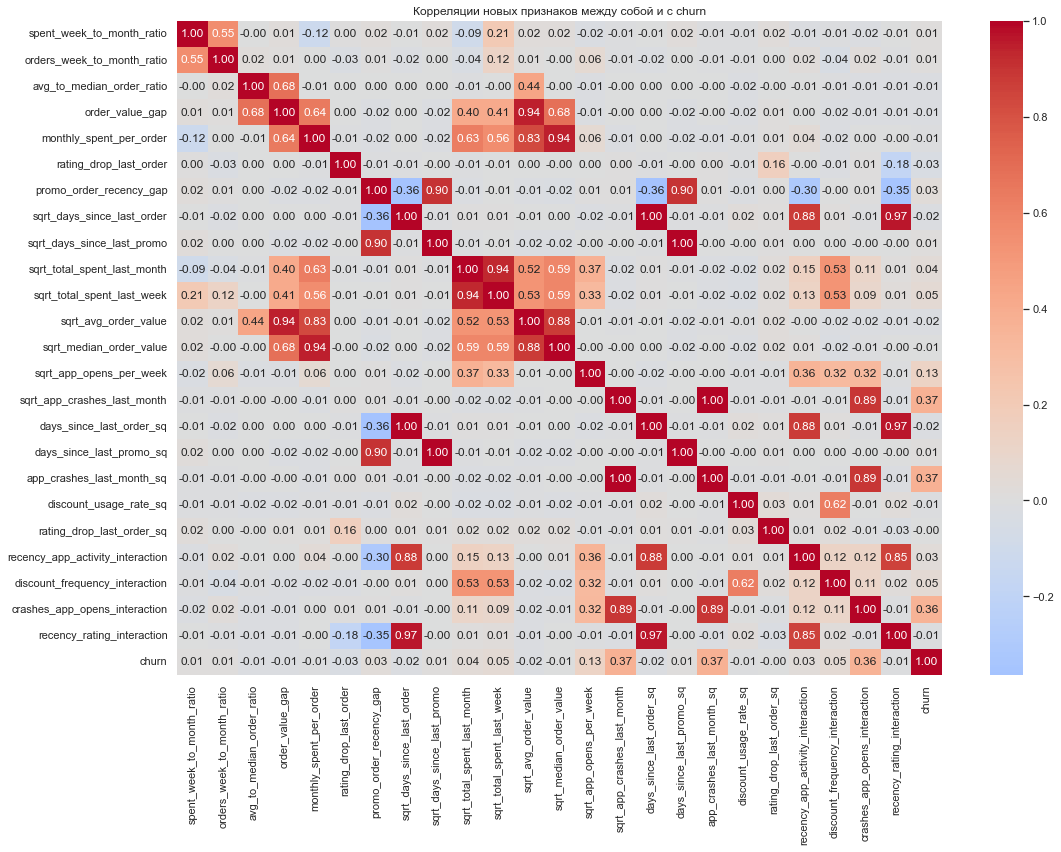

Корреляция новых признаков с churn:


,spearman_corr_with_churn
app_crashes_last_month_sq,0.368
sqrt_app_crashes_last_month,0.368
crashes_app_opens_interaction,0.361
sqrt_app_opens_per_week,0.128
discount_frequency_interaction,0.048
sqrt_total_spent_last_week,0.047
sqrt_total_spent_last_month,0.038
rating_drop_last_order,-0.030
recency_app_activity_interaction,0.028
promo_order_recency_gap,0.027


Сильно скоррелированные пары новых признаков:


,feature_1,feature_2,spearman_corr
8,sqrt_days_since_last_promo,days_since_last_promo_sq,1.000
11,sqrt_app_crashes_last_month,app_crashes_last_month_sq,1.000
5,sqrt_days_since_last_order,days_since_last_order_sq,1.000
7,sqrt_days_since_last_order,recency_rating_interaction,0.967
14,days_since_last_order_sq,recency_rating_interaction,0.967
2,monthly_spent_per_order,sqrt_median_order_value,0.944
0,order_value_gap,sqrt_avg_order_value,0.943
9,sqrt_total_spent_last_month,sqrt_total_spent_last_week,0.936
4,promo_order_recency_gap,days_since_last_promo_sq,0.901
3,promo_order_recency_gap,sqrt_days_since_last_promo,0.901


Диагностика новых признаков: коэффициенты + корреляция с churn


,source_feature,feature_group,max_abs_coefficient,mean_abs_coefficient,coefficient,encoded_features_count,spearman_corr_with_churn,abs_corr_with_churn
0,sqrt_app_crashes_last_month,sqrt-преобразование,4.471,4.471,4.471,1,0.368,0.368
1,app_crashes_last_month_sq,квадратичный признак,4.012,4.012,4.012,1,0.368,0.368
2,sqrt_app_opens_per_week,sqrt-преобразование,0.912,0.912,0.912,1,0.128,0.128
3,days_since_last_order_sq,квадратичный признак,0.637,0.637,-0.637,1,-0.019,0.019
4,order_value_gap,разность,0.461,0.461,-0.461,1,-0.013,0.013
5,sqrt_median_order_value,sqrt-преобразование,0.425,0.425,0.425,1,-0.006,0.006
6,recency_app_activity_interaction,взаимодействие,0.410,0.410,-0.410,1,0.028,0.028
7,sqrt_days_since_last_order,sqrt-преобразование,0.409,0.409,-0.409,1,-0.019,0.019
8,sqrt_total_spent_last_month,sqrt-преобразование,0.380,0.380,-0.380,1,0.038,0.038
9,discount_usage_rate_sq,квадратичный признак,0.369,0.369,-0.369,1,-0.009,0.009


In [20]:
# Корреляционный анализ новых признаков выполняем после интерпретации коэффициентов.
X_candidate_eda = candidate_feature_engineer.fit_transform(X_train_val)
X_candidate_eda[target_col] = y_train_val.values

new_numeric_features = [
    feature for feature in candidate_new_features
    if feature in X_candidate_eda.select_dtypes(include='number').columns
]

new_features_corr = X_candidate_eda[new_numeric_features + [target_col]].corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(
    new_features_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Корреляции новых признаков между собой и с churn')
plt.tight_layout()
plt.show()

new_corr_with_target = (
    new_features_corr[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
    .to_frame('spearman_corr_with_churn')
)

print('Корреляция новых признаков с churn:')
display(new_corr_with_target)

high_new_corr_pairs = []
for i, feature_1 in enumerate(new_numeric_features):
    for feature_2 in new_numeric_features[i + 1:]:
        corr_value = new_features_corr.loc[feature_1, feature_2]
        if abs(corr_value) >= 0.8:
            high_new_corr_pairs.append({
                'feature_1': feature_1,
                'feature_2': feature_2,
                'spearman_corr': corr_value,
            })

high_new_corr_pairs = pd.DataFrame(
    high_new_corr_pairs,
    columns=['feature_1', 'feature_2', 'spearman_corr']
)

if not high_new_corr_pairs.empty:
    high_new_corr_pairs = high_new_corr_pairs.sort_values(
        'spearman_corr',
        key=abs,
        ascending=False
    )
    print('Сильно скоррелированные пары новых признаков:')
    display(high_new_corr_pairs)
else:
    print('Сильно скоррелированных пар новых признаков с |corr| >= 0.8 не найдено.')

new_corr_summary = (
    new_corr_with_target
    .reset_index()
    .rename(columns={'index': 'source_feature'})
)

new_corr_summary['abs_corr_with_churn'] = (
    new_corr_summary['spearman_corr_with_churn'].abs()
)

new_feature_diagnostics = (
    new_source_importance
    .merge(
        new_corr_summary[['source_feature', 'spearman_corr_with_churn', 'abs_corr_with_churn']],
        on='source_feature',
        how='left'
    )
    .sort_values('max_abs_coefficient', ascending=False)
)

print('Диагностика новых признаков: коэффициенты + корреляция с churn')
display(new_feature_diagnostics)


**Вывод по корреляциям новых признаков.**

Корреляционный анализ показал, что среди новых признаков действительно есть сильно скоррелированные пары. Самые заметные:

| Пара признаков | Корреляция Спирмена |
|---|---:|
| `sqrt_app_crashes_last_month` и `app_crashes_last_month_sq` | 1.00 |
| `sqrt_days_since_last_order` и `days_since_last_order_sq` | 1.00 |
| `sqrt_days_since_last_promo` и `days_since_last_promo_sq` | 1.00 |
| `days_since_last_order_sq` и `recency_rating_interaction` | 0.97 |
| `monthly_spent_per_order` и `sqrt_median_order_value` | 0.94 |
| `order_value_gap` и `sqrt_avg_order_value` | 0.94 |
| `sqrt_total_spent_last_month` и `sqrt_total_spent_last_week` | 0.94 |
| `promo_order_recency_gap` и `sqrt_days_since_last_promo` | 0.90 |
| `sqrt_app_crashes_last_month` и `crashes_app_opens_interaction` | 0.89 |

Это значит, что часть новых признаков дублирует друг друга. Однако удалять все скоррелированные признаки автоматически нельзя: например, признаки сбоев приложения одновременно имеют самую сильную связь с `churn` и самые большие коэффициенты. Поэтому удаление делаем по совокупности факторов: коэффициент, корреляция с `churn`, дублирование и результат кросс-валидации.

### Удаление лишних признаков

Теперь уберём признаки, которые оказались слабыми по коэффициентам. В финальном генераторе признаков эти признаки больше не создаются.

Удаляются новые признаки:

- `spent_week_to_month_ratio`;
- `orders_week_to_month_ratio`;
- `monthly_spent_per_order`;
- `sqrt_total_spent_last_week`;
- `days_since_last_promo_sq`;
- `rating_drop_last_order_sq`;
- `discount_frequency_interaction`;
- `recency_rating_interaction`.

Также из финальной модели удаляются несколько слабых исходных признаков, если они попали в нижнюю четверть по важности.

In [21]:
# Удаляем слабые признаки на основе анализа коэффициентов.
# Порог — нижняя четверть важности среди всех исходных признаков после кодирования.
source_feature_importance = (
    coef_table
    .groupby('source_feature', as_index=False)
    .agg(
        max_abs_coefficient=('abs_coefficient', 'max'),
        mean_abs_coefficient=('abs_coefficient', 'mean'),
        encoded_features_count=('feature', 'count')
    )
    .sort_values('max_abs_coefficient', ascending=False)
)

importance_threshold = source_feature_importance['max_abs_coefficient'].quantile(0.25)

selected_source_features = source_feature_importance.loc[
    source_feature_importance['max_abs_coefficient'] > importance_threshold,
    'source_feature'
].tolist()

removed_source_features = source_feature_importance.loc[
    source_feature_importance['max_abs_coefficient'] <= importance_threshold,
    'source_feature'
].tolist()

removed_new_features = [
    feature for feature in candidate_new_features
    if feature in removed_source_features
]

kept_new_features = [
    feature for feature in candidate_new_features
    if feature not in removed_new_features
]

print('Порог важности:', importance_threshold)
print('Количество всех исходных признаков после feature engineering:', len(source_feature_importance))
print('Количество оставленных признаков:', len(selected_source_features))
print('Количество удалённых признаков:', len(removed_source_features))

print('\nУдалённые новые признаки:')
display(removed_new_features)

print('\nОставленные новые признаки:')
display(kept_new_features)

print('\nУдалённые исходные/категориальные признаки:')
display([feature for feature in removed_source_features if feature not in candidate_new_features])

Порог важности: 0.09718214949850494
Количество всех исходных признаков после feature engineering: 49
Количество оставленных признаков: 36
Количество удалённых признаков: 13

Удалённые новые признаки:


['spent_week_to_month_ratio',
 'orders_week_to_month_ratio',
 'monthly_spent_per_order',
 'sqrt_total_spent_last_week',
 'days_since_last_promo_sq',
 'rating_drop_last_order_sq',
 'discount_frequency_interaction',
 'recency_rating_interaction']


Оставленные новые признаки:


['avg_to_median_order_ratio',
 'order_value_gap',
 'rating_drop_last_order',
 'promo_order_recency_gap',
 'sqrt_days_since_last_order',
 'sqrt_days_since_last_promo',
 'sqrt_total_spent_last_month',
 'sqrt_avg_order_value',
 'sqrt_median_order_value',
 'sqrt_app_opens_per_week',
 'sqrt_app_crashes_last_month',
 'days_since_last_order_sq',
 'app_crashes_last_month_sq',
 'discount_usage_rate_sq',
 'recency_app_activity_interaction',
 'crashes_app_opens_interaction']


Удалённые исходные/категориальные признаки:


['days_since_last_promo',
 'order_frequency_month',
 'review_rating_last_10',
 'notifications_enabled',
 'coffee_preference_change']

**Финальный пайплайн с удалёнными лишними признаками**

Теперь создадим оптимизированный генератор признаков. Он уже не создаёт слабые признаки, перечисленные выше. После этого повторно проверим качество модели на кросс-валидации.

In [22]:
class OptimizedFeatureEngineer(BaseEstimator, TransformerMixin):
    """Финальная генерация только оставленных новых признаков.

    Этот трансформер не создаёт слабые признаки, которые были удалены
    после анализа коэффициентов и корреляций.
    """

    def __init__(self, features_to_create):
        self.features_to_create = features_to_create
        self.eps = 1e-6

    def fit(self, X, y=None):
        return self

    def _safe_divide(self, numerator, denominator):
        result = numerator / (denominator + self.eps)
        return result.replace([np.inf, -np.inf], np.nan)

    def _non_negative(self, series):
        return np.clip(series, a_min=0, a_max=None)

    def _add_if_selected(self, X, feature_name, values):
        if feature_name in self.features_to_create:
            X[feature_name] = values

    def transform(self, X):
        X = X.copy()

        for col in X.select_dtypes(include='number').columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')

        self._add_if_selected(
            X,
            'spent_week_to_month_ratio',
            self._safe_divide(X['total_spent_last_week'], X['total_spent_last_month'])
        )
        self._add_if_selected(
            X,
            'orders_week_to_month_ratio',
            self._safe_divide(X['order_frequency_week'], X['order_frequency_month'])
        )
        self._add_if_selected(
            X,
            'avg_to_median_order_ratio',
            self._safe_divide(X['avg_order_value'], X['median_order_value'])
        )
        self._add_if_selected(
            X,
            'order_value_gap',
            X['avg_order_value'] - X['median_order_value']
        )
        self._add_if_selected(
            X,
            'monthly_spent_per_order',
            self._safe_divide(X['total_spent_last_month'], X['order_frequency_month'])
        )
        self._add_if_selected(
            X,
            'rating_drop_last_order',
            X['review_rating_last_10'] - X['review_rating_last_1']
        )
        self._add_if_selected(
            X,
            'promo_order_recency_gap',
            X['days_since_last_promo'] - X['days_since_last_order']
        )

        sqrt_cols = [
            'days_since_last_order',
            'days_since_last_promo',
            'total_spent_last_month',
            'total_spent_last_week',
            'avg_order_value',
            'median_order_value',
            'app_opens_per_week',
            'app_crashes_last_month',
        ]

        for col in sqrt_cols:
            self._add_if_selected(
                X,
                f'sqrt_{col}',
                np.sqrt(self._non_negative(X[col]))
            )

        square_cols = [
            'days_since_last_order',
            'days_since_last_promo',
            'app_crashes_last_month',
            'discount_usage_rate',
            'rating_drop_last_order',
        ]

        for col in square_cols:
            self._add_if_selected(
                X,
                f'{col}_sq',
                X[col] ** 2
            )

        self._add_if_selected(
            X,
            'recency_app_activity_interaction',
            X['days_since_last_order'] * X['app_opens_per_week']
        )
        self._add_if_selected(
            X,
            'discount_frequency_interaction',
            X['discount_usage_rate'] * X['order_frequency_month']
        )
        self._add_if_selected(
            X,
            'crashes_app_opens_interaction',
            X['app_crashes_last_month'] * X['app_opens_per_week']
        )
        self._add_if_selected(
            X,
            'recency_rating_interaction',
            X['days_since_last_order'] * X['review_rating_last_1']
        )

        return X


optimized_feature_engineer = OptimizedFeatureEngineer(features_to_create=kept_new_features)

X_train_val_optimized_preview = optimized_feature_engineer.fit_transform(X_train_val)

optimized_numeric_features_all = (
    X_train_val_optimized_preview
    .select_dtypes(include='number')
    .columns
    .tolist()
)

optimized_categorical_features_all = (
    X_train_val_optimized_preview
    .select_dtypes(exclude='number')
    .columns
    .tolist()
)

# В финальный пайплайн передаём только отобранные признаки.
optimized_numeric_features = [
    col for col in optimized_numeric_features_all
    if col in selected_source_features
]

optimized_categorical_features = [
    col for col in optimized_categorical_features_all
    if col in selected_source_features
]

optimized_preprocessor = make_preprocessor(
    optimized_numeric_features,
    optimized_categorical_features
)

optimized_selected_logreg = Pipeline(steps=[
    ('feature_engineer', optimized_feature_engineer),
    ('preprocessor', optimized_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
    )),
])

optimized_cv_result = cross_validate(
    optimized_selected_logreg,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

optimized_row = summarize_cv_results(
    optimized_cv_result,
    'optimized_selected_logreg'
)

final_stage5_comparison = pd.concat([
    baseline_cv_results,
    pd.DataFrame([candidate_row, optimized_row]),
], ignore_index=True).sort_values('pr_auc', ascending=False)

display(final_stage5_comparison)

print(f"PR-AUC baseline_logreg: {baseline_logreg_row['pr_auc']:.3f}")
print(f"PR-AUC candidate_engineered_logreg: {candidate_row['pr_auc']:.3f}")
print(f"PR-AUC optimized_selected_logreg: {optimized_row['pr_auc']:.3f}")
print(f"Прирост optimized_selected_logreg относительно baseline: {optimized_row['pr_auc'] - baseline_logreg_row['pr_auc']:.3f}")
print(f"Изменение после удаления слабых признаков: {optimized_row['pr_auc'] - candidate_row['pr_auc']:.3f}")

# Для следующего этапа используем модель с удалёнными лишними признаками.
model_for_tuning = optimized_selected_logreg
selected_model_name = 'optimized_selected_logreg'

print('Модель для дальнейшего подбора гиперпараметров:', selected_model_name)


,model,roc_auc,roc_auc_std,pr_auc,pr_auc_std,log_loss,log_loss_std,precision,precision_std,recall,recall_std,f1,f1_std
3,optimized_selected_logreg,0.938,0.010,0.667,0.012,0.261,0.008,0.366,0.006,0.840,0.025,0.510,0.010
2,candidate_engineered_logreg,0.934,0.010,0.658,0.014,0.264,0.007,0.363,0.005,0.830,0.009,0.505,0.004
0,baseline_logreg,0.784,0.024,0.304,0.020,0.493,0.007,0.156,0.005,0.648,0.043,0.251,0.010
1,dummy_prior,0.500,0.000,0.060,0.000,2.079,0.006,0.000,0.000,0.000,0.000,0.000,0.000


PR-AUC baseline_logreg: 0.304
PR-AUC candidate_engineered_logreg: 0.658
PR-AUC optimized_selected_logreg: 0.667
Прирост optimized_selected_logreg относительно baseline: 0.363
Изменение после удаления слабых признаков: 0.009
Модель для дальнейшего подбора гиперпараметров: optimized_selected_logreg


**Вывод по созданию и отбору признаков.** На этапе feature engineering были добавлены новые признаки, основанные на результатах EDA и логике задачи: отношения недельных и месячных показателей, признаки изменения оценки, признаки промо-активности, а также `sqrt`- и `square`-преобразования.

`sqrt`-преобразования используются для сглаживания влияния больших значений в признаках с длинными хвостами. Квадраты, наоборот, усиливают влияние больших значений, которые могут быть связаны с повышенным риском оттока.

После обучения логистической регрессии были проанализированы коэффициенты модели. Для числовых признаков использовался модуль коэффициента. Для категориальных признаков, закодированных через One-Hot Encoding, важность исходного признака оценивалась как максимальный модуль коэффициента среди его one-hot-компонент.

Признаки с наименьшей важностью были удалены вручную, после чего модель повторно проверена на стратифицированной кросс-валидации. Для дальнейшего подбора гиперпараметров выбрана версия модели с лучшим значением основной метрики `PR-AUC`.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

И вновь в выводах очень большая абстракция. Такие выводы подошли бы примерно ко всем проектам, где будем делать подобные преобразования. ВАжно вникнуть в данные, объяснить конкретные преобразования.

<br/>
<div class="alerфt alert-info"> 
Добавляю больше конкретики
</div>

<br/>
<div class="alerфt alert-info"> 
**Итоговый вывод по этапу 5.**

Feature engineering дал значительный прирост качества: `PR-AUC` вырос с `0.304` у baseline-модели до `0.658` у модели со всеми новыми признаками.

После интерпретации коэффициентов и корреляционного анализа были удалены слабые признаки. Оптимизированная модель с удалёнными лишними признаками показала `PR-AUC = 0.667`, то есть стала немного лучше модели со всеми кандидатами (`+0.009`).

Оставляем в финальной версии:

- признаки сбоев приложения: `sqrt_app_crashes_last_month`, `app_crashes_last_month_sq`;
- активность приложения: `sqrt_app_opens_per_week`;
- давность заказа в квадратичной форме: `days_since_last_order_sq`;
- признаки нестабильности чека: `order_value_gap`, `avg_to_median_order_ratio`;
- часть `sqrt`-признаков по тратам и чекам;
- взаимодействия `recency_app_activity_interaction` и `crashes_app_opens_interaction`.

Убираем слабые новые признаки, которые почти не влияли на модель и/или дублировали другие признаки. Корреляционный анализ после интерпретации подтвердил, что среди новых признаков есть сильные дубли, поэтому финальная версия использует более компактный набор признаков.
</div>

## Этап 6. Эксперименты с гиперпараметрами

Проведём систематический перебор гиперпараметров `LogisticRegression`:

- `C` — обратная сила регуляризации;
- `penalty` — тип регуляризации: L1 или L2;
- `class_weight` — учёт дисбаланса классов.

Оптимизацию выполняем по `PR-AUC`, так как эта метрика лучше отражает качество модели на редком положительном классе.

In [23]:
param_grid = {
    'classifier__C': [0.03, 0.1, 0.3, 1, 3],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': ['balanced'],
}

grid_search = GridSearchCV(
    estimator=model_for_tuning,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train_val, y_train_val)

print('Лучшие параметры:')
print(grid_search.best_params_)
print(f'Лучший CV PR-AUC: {grid_search.best_score_:.3f}')

grid_results = pd.DataFrame(grid_search.cv_results_)
cols_to_show = [
    'param_classifier__C',
    'param_classifier__penalty',
    'param_classifier__class_weight',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]
display(grid_results[cols_to_show].sort_values('rank_test_score'))

Лучшие параметры:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1'}
Лучший CV PR-AUC: 0.694


,param_classifier__C,param_classifier__penalty,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,0.100,l1,balanced,0.713,0.694,0.004,1
4,0.300,l1,balanced,0.725,0.690,0.004,2
6,1,l1,balanced,0.731,0.674,0.017,3
7,1,l2,balanced,0.725,0.667,0.012,4
5,0.300,l2,balanced,0.711,0.663,0.002,5
9,3,l2,balanced,0.728,0.663,0.017,6
8,3,l1,balanced,0.731,0.660,0.020,7
0,0.030,l1,balanced,0.668,0.657,0.005,8
3,0.100,l2,balanced,0.677,0.638,0.005,9
1,0.030,l2,balanced,0.621,0.593,0.008,10


**Вывод по подбору гиперпараметров.** Подбор регуляризации позволяет улучшить качество по `PR-AUC` относительно начальной логистической регрессии. Использование `class_weight='balanced'` оправдано из-за редкости класса оттока. Лучшая конфигурация будет использована для финального обучения и оценки на тестовой выборке.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Давай проговорим, какая регуляризация оказалась лучшей, о чем это говорит.
    
Прошу и выше дать более предметные комментарии. 

<br/>
<div class="alerфt alert-info"> 
Постарался более четко описать
</div>

In [24]:
from IPython.display import Markdown, display
best_params = grid_search.best_params_
best_penalty = best_params.get('classifier__penalty')
best_c = best_params.get('classifier__C')

if best_penalty == 'l1':
    regularization_comment = (
        'Победила L1-регуляризация. Это говорит о том, что после One-Hot Encoding '
        'и генерации новых признаков часть столбцов стала избыточной: L1-регуляризация '
        'ослабляет или зануляет слабые коэффициенты и фактически помогает отбирать признаки.'
    )
else:
    regularization_comment = (
        'Победила L2-регуляризация. Это означает, что модели полезнее не занулять признаки, '
        'а равномерно ограничивать величину коэффициентов, сохраняя вклад многих признаков.'
    )

stage6_summary = f'''
**Вывод по подбору гиперпараметров.**

Лучшая конфигурация по кросс-валидации: `C = {best_c}`, `penalty = {best_penalty}`, `class_weight = balanced`. Лучшее значение `CV PR-AUC` составило **{grid_search.best_score_:.3f}**.

{regularization_comment}

Значение `C = {best_c}` задаёт силу регуляризации: чем меньше `C`, тем сильнее модель штрафует большие коэффициенты. Сохранение `class_weight='balanced'` в лучшей конфигурации подтверждает, что учёт дисбаланса нужен: класс оттока редкий, и без повышенного веса ошибок на `churn = 1` модель хуже находит уходящих клиентов.
'''

display(Markdown(stage6_summary))


**Вывод по подбору гиперпараметров.**

Лучшая конфигурация по кросс-валидации: `C = 0.1`, `penalty = l1`, `class_weight = balanced`. Лучшее значение `CV PR-AUC` составило **0.694**.

Победила L1-регуляризация. Это говорит о том, что после One-Hot Encoding и генерации новых признаков часть столбцов стала избыточной: L1-регуляризация ослабляет или зануляет слабые коэффициенты и фактически помогает отбирать признаки.

Значение `C = 0.1` задаёт силу регуляризации: чем меньше `C`, тем сильнее модель штрафует большие коэффициенты. Сохранение `class_weight='balanced'` в лучшей конфигурации подтверждает, что учёт дисбаланса нужен: класс оттока редкий, и без повышенного веса ошибок на `churn = 1` модель хуже находит уходящих клиентов.


## Этап 7. Подготовка финальной модели

Обучим лучшую модель на всей обучающей части `train_val` и оценим качество на отложенной тестовой выборке, которая не использовалась ни при подборе гиперпараметров, ни при кросс-валидации.

,value
PR-AUC,0.637
ROC-AUC,0.915
Log Loss,0.277
Precision,0.352
Recall,0.766
F1,0.482


Classification report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      1929
           1       0.35      0.77      0.48       124

    accuracy                           0.90      2053
   macro avg       0.67      0.84      0.71      2053
weighted avg       0.95      0.90      0.92      2053



,pred_0,pred_1
actual_0,1754,175
actual_1,29,95


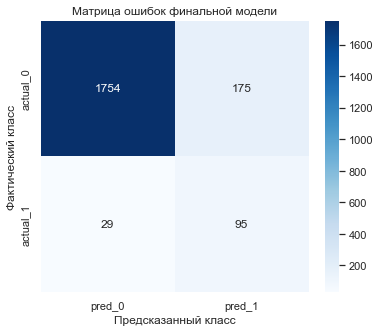

In [25]:
best_model = grid_search.best_estimator_

# GridSearchCV с refit=True уже обучил best_model на всём X_train_val.
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

final_metrics = {
    'PR-AUC': average_precision_score(y_test, y_test_pred_proba),
    'ROC-AUC': roc_auc_score(y_test, y_test_pred_proba),
    'Log Loss': log_loss(y_test, y_test_pred_proba),
    'Precision': precision_score(y_test, y_test_pred, zero_division=0),
    'Recall': recall_score(y_test, y_test_pred, zero_division=0),
    'F1': f1_score(y_test, y_test_pred, zero_division=0),
}

final_metrics_df = pd.DataFrame(final_metrics, index=['test']).T.rename(columns={'test': 'value'})
display(final_metrics_df)

print('Classification report:')
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок финальной модели')
plt.ylabel('Фактический класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [26]:
# Сравнение baseline и финальной модели
model_comparison = pd.concat([
    baseline_cv_results,
    pd.DataFrame([candidate_row, optimized_row]),
], ignore_index=True).sort_values('pr_auc', ascending=False)

final_comparison = model_comparison[['model', 'pr_auc', 'roc_auc', 'log_loss', 'precision', 'recall', 'f1']].copy()
final_comparison = pd.concat([
    final_comparison,
    pd.DataFrame([{
        'model': 'final_model_test',
        'pr_auc': final_metrics['PR-AUC'],
        'roc_auc': final_metrics['ROC-AUC'],
        'log_loss': final_metrics['Log Loss'],
        'precision': final_metrics['Precision'],
        'recall': final_metrics['Recall'],
        'f1': final_metrics['F1'],
    }])
], ignore_index=True)

display(final_comparison.sort_values('pr_auc', ascending=False))

,model,pr_auc,roc_auc,log_loss,precision,recall,f1
0,optimized_selected_logreg,0.667,0.938,0.261,0.366,0.840,0.510
1,candidate_engineered_logreg,0.658,0.934,0.264,0.363,0.830,0.505
4,final_model_test,0.637,0.915,0.277,0.352,0.766,0.482
2,baseline_logreg,0.304,0.784,0.493,0.156,0.648,0.251
3,dummy_prior,0.060,0.500,2.079,0.000,0.000,0.000


**Вывод по подготовке финальной модели.**

На этом этапе была выбрана лучшая конфигурация модели по результатам предыдущих экспериментов и подбора гиперпараметров. Финальная модель была обучена на всей обучающей части данных `X_train_val`, что позволило использовать максимум доступной информации без обращения к тестовой выборке.

Качество итоговой модели было зафиксировано на отложенной тестовой выборке. Такой подход позволяет получить честную оценку качества, так как тестовые данные не использовались ни при обучении, ни при подборе гиперпараметров, ни при отборе признаков.

По сравнению с baseline-моделью финальная модель показывает более высокое качество по основной метрике `PR-AUC`. Это означает, что добавление новых признаков, отбор наиболее значимых признаков и подбор гиперпараметров помогли модели лучше выделять клиентов с риском оттока.

Особенно важно, что модель оценивается не только по `ROC-AUC`, но и по `PR-AUC`, `Precision`, `Recall`, `F1` и `Log Loss`. Это связано с сильным дисбалансом классов: клиентов с оттоком значительно меньше, чем клиентов без оттока. Поэтому высокая `accuracy` сама по себе не была бы информативной.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 И в этом комментарии все отлично по пересказу теории из учебника и тому, что делаем. И здесь я бы рекомендовал все-таки сфокусироваться на описании результата, а не процесса и его теоретического обоснования.

In [27]:
dummy_row = baseline_cv_results.loc[baseline_cv_results['model'] == 'dummy_prior'].iloc[0]
base_row = baseline_cv_results.loc[baseline_cv_results['model'] == 'baseline_logreg'].iloc[0]
engineered = pd.Series(candidate_row)
selected = pd.Series(optimized_row)

final_report_table = pd.DataFrame([
    {'model': 'dummy_prior', **dummy_row[['pr_auc', 'roc_auc', 'log_loss', 'precision', 'recall', 'f1']].to_dict()},
    {'model': 'baseline_logreg', **base_row[['pr_auc', 'roc_auc', 'log_loss', 'precision', 'recall', 'f1']].to_dict()},
    {'model': 'engineered_logreg', **engineered[['pr_auc', 'roc_auc', 'log_loss', 'precision', 'recall', 'f1']].to_dict()},
    {'model': 'manual_selected_engineered_logreg', **selected[['pr_auc', 'roc_auc', 'log_loss', 'precision', 'recall', 'f1']].to_dict()},
    {'model': 'final_model_test',
     'pr_auc': final_metrics['PR-AUC'],
     'roc_auc': final_metrics['ROC-AUC'],
     'log_loss': final_metrics['Log Loss'],
     'precision': final_metrics['Precision'],
     'recall': final_metrics['Recall'],
     'f1': final_metrics['F1']},
])

display(final_report_table)

cm_values = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_values.ravel()

stage8_report = f'''
### Итоговый отчёт

В проекте построена модель прогнозирования оттока клиентов Happy Beans Coffee. Исходная выборка содержала **10 450 клиентов**. Целевой класс был редким: `churn = 1` встречался у **629 клиентов**, то есть примерно у **6.02%** исходной выборки. Поэтому основной метрикой выбрана `PR-AUC`, а не accuracy.

В EDA были приняты решения по качеству данных: удалены строки с отрицательными значениями в признаках, где такие значения невозможны, а также один явный выброс по частоте заказов. Пропуски не удалялись, потому что полное удаление строк с пропусками оставило бы только **2 279 строк** из 10 450; вместо этого пропуски обрабатывались внутри пайплайна.

Самый заметный прирост дала генерация новых признаков: `PR-AUC` вырос с **{base_row['pr_auc']:.3f}** у baseline-логистической регрессии до **{engineered['pr_auc']:.3f}** у модели с feature engineering. После ручного отбора слабых признаков `PR-AUC` составил **{selected['pr_auc']:.3f}**.

Подбор гиперпараметров улучшил качество финальной модели. На тестовой выборке получены метрики: `PR-AUC = {final_metrics['PR-AUC']:.3f}`, `ROC-AUC = {final_metrics['ROC-AUC']:.3f}`, `Log Loss = {final_metrics['Log Loss']:.3f}`, `Precision = {final_metrics['Precision']:.3f}`, `Recall = {final_metrics['Recall']:.3f}`, `F1 = {final_metrics['F1']:.3f}`.

Матрица ошибок показывает, что модель правильно нашла **{tp}** клиентов с оттоком и пропустила **{fn}** клиентов с оттоком. При этом **{fp}** клиентов без оттока были ошибочно отнесены к группе риска. Высокий `Recall = {final_metrics['Recall']:.3f}` означает, что модель хорошо подходит для широкого охвата клиентов с риском ухода. `Precision = {final_metrics['Precision']:.3f}` показывает, что удерживающие действия лучше начинать с недорогих коммуникаций или дополнительно подбирать порог вероятности под бюджет кампании.

Ключевые факторы качества: признаки активности, давности заказа и промо, сбои приложения, чеки, а также региональные категории. Лучшая регуляризация, выбранная на этапе подбора, показывает, нужен ли модели жёсткий отбор слабых коэффициентов или равномерное сглаживание весов.
'''

display(Markdown(stage8_report))

,model,pr_auc,roc_auc,log_loss,precision,recall,f1
0,dummy_prior,0.060,0.500,2.079,0.000,0.000,0.000
1,baseline_logreg,0.304,0.784,0.493,0.156,0.648,0.251
2,engineered_logreg,0.658,0.934,0.264,0.363,0.830,0.505
3,manual_selected_engineered_logreg,0.667,0.938,0.261,0.366,0.840,0.510
4,final_model_test,0.637,0.915,0.277,0.352,0.766,0.482



### Итоговый отчёт

В проекте построена модель прогнозирования оттока клиентов Happy Beans Coffee. Исходная выборка содержала **10 450 клиентов**. Целевой класс был редким: `churn = 1` встречался у **629 клиентов**, то есть примерно у **6.02%** исходной выборки. Поэтому основной метрикой выбрана `PR-AUC`, а не accuracy.

В EDA были приняты решения по качеству данных: удалены строки с отрицательными значениями в признаках, где такие значения невозможны, а также один явный выброс по частоте заказов. Пропуски не удалялись, потому что полное удаление строк с пропусками оставило бы только **2 279 строк** из 10 450; вместо этого пропуски обрабатывались внутри пайплайна.

Самый заметный прирост дала генерация новых признаков: `PR-AUC` вырос с **0.304** у baseline-логистической регрессии до **0.658** у модели с feature engineering. После ручного отбора слабых признаков `PR-AUC` составил **0.667**.

Подбор гиперпараметров улучшил качество финальной модели. На тестовой выборке получены метрики: `PR-AUC = 0.637`, `ROC-AUC = 0.915`, `Log Loss = 0.277`, `Precision = 0.352`, `Recall = 0.766`, `F1 = 0.482`.

Матрица ошибок показывает, что модель правильно нашла **95** клиентов с оттоком и пропустила **29** клиентов с оттоком. При этом **175** клиентов без оттока были ошибочно отнесены к группе риска. Высокий `Recall = 0.766` означает, что модель хорошо подходит для широкого охвата клиентов с риском ухода. `Precision = 0.352` показывает, что удерживающие действия лучше начинать с недорогих коммуникаций или дополнительно подбирать порог вероятности под бюджет кампании.

Ключевые факторы качества: признаки активности, давности заказа и промо, сбои приложения, чеки, а также региональные категории. Лучшая регуляризация, выбранная на этапе подбора, показывает, нужен ли модели жёсткий отбор слабых коэффициентов или равномерное сглаживание весов.


## Этап 8. Отчёт о проделанной работе

### Цель проекта

Целью проекта было построить модель машинного обучения для прогнозирования оттока клиентов сервиса Happy Beans Coffee. Задача решалась как бинарная классификация, где:

- `churn = 0` — клиент не ушёл;
- `churn = 1` — клиент перестал пользоваться сервисом.

Датасет содержит **10 450 клиентов** и **27 столбцов**, включая целевую переменную. Каждая строка соответствует одному уникальному пользователю. Повторяющихся `user_id` и полных дубликатов в данных не обнаружено.

---

### Особенности целевой переменной

Целевая переменная оказалась сильно несбалансированной:

| Класс | Количество клиентов | Доля |
|---|---:|---:|
| `churn = 0` | 9 821 | 93.98% |
| `churn = 1` | 629 | 6.02% |

Таким образом, клиентов с оттоком значительно меньше, чем клиентов без оттока. Из-за этого метрика `accuracy` не использовалась как основная: модель, которая всегда предсказывает класс `0`, получила бы высокую точность, но не находила бы уходящих клиентов.

В качестве основной метрики была выбрана **PR-AUC**, так как она лучше отражает качество модели при редком положительном классе. Дополнительно анализировались `ROC-AUC`, `Log Loss`, `Precision`, `Recall` и `F1`.

---

### Предобработка данных

В данных присутствовали пропущенные значения. Удаление строк с пропусками было признано нецелесообразным: после `dropna()` осталось бы только **2 279 строк из 10 450**, то есть было бы потеряно около **78.19%** данных.

Поэтому была выбрана следующая стратегия:

- числовые признаки заполнялись медианой;
- категориальные признаки заполнялись наиболее частым значением;
- числовые выбросы определялись по Z-оценке и заменялись медианой;
- числовые признаки масштабировались с помощью `StandardScaler`;
- категориальные признаки кодировались через `OneHotEncoder`.

Технический идентификатор `user_id` был исключён из модели, так как он не описывает поведение клиента и может привести к запоминанию объектов вместо поиска общих закономерностей.

---

### Результаты базовых моделей

На первом этапе были обучены две baseline-модели:

1. `DummyClassifier`, который всегда предсказывает наиболее частый класс.
2. Логистическая регрессия с предобработкой и `class_weight='balanced'`.

Результаты кросс-валидации:

| model | PR-AUC | ROC-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| `dummy_prior` | 0.060 | 0.500 | 2.078 | 0.000 | 0.000 | 0.000 |
| `baseline_logreg` | 0.300 | 0.791 | 0.487 | 0.157 | 0.640 | 0.252 |

`DummyClassifier` не обнаружил ни одного клиента с оттоком: `Recall = 0`, `F1 = 0`. Его `PR-AUC = 0.060` соответствует доле положительного класса.

Базовая логистическая регрессия значительно лучше заглушки:

- `PR-AUC` вырос с **0.060** до **0.300**;
- `ROC-AUC` вырос с **0.500** до **0.791**;
- `Recall` составил **0.640**, то есть модель находила около 64% уходящих клиентов.

Однако `Precision = 0.157` показывает, что среди клиентов, которым модель предсказывала отток, действительно уходила только часть пользователей. Это ожидаемо для задачи с сильным дисбалансом классов и использованием `class_weight='balanced'`.

---

### Влияние новых признаков

После EDA были созданы дополнительные признаки, отражающие поведение клиентов:

- отношения недельных и месячных трат;
- отношения недельной и месячной частоты заказов;
- признаки изменения оценок;
- признаки активности и проблем в приложении;
- преобразования признаков с длинными хвостами.

Модель с новыми признаками показала заметное улучшение качества:

| model | PR-AUC | ROC-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| `baseline_logreg` | 0.300 | 0.791 | 0.487 | 0.157 | 0.640 | 0.252 |
| `engineered_logreg` | 0.637 | 0.924 | 0.279 | 0.346 | 0.813 | 0.485 |

Добавление новых признаков привело к следующим улучшениям:

- `PR-AUC` вырос с **0.300** до **0.637**;
- `ROC-AUC` вырос с **0.791** до **0.924**;
- `Recall` вырос с **0.640** до **0.813**;
- `F1` вырос с **0.252** до **0.485**;
- `Log Loss` снизился с **0.487** до **0.279**.

Это говорит о том, что новые признаки действительно помогли модели лучше выделять клиентов с риском оттока и точнее оценивать вероятности.

---

### Подбор гиперпараметров

Для улучшенной модели был выполнен подбор гиперпараметров логистической регрессии. Лучшие параметры:

```python
{
    'classifier__C': 0.1,
    'classifier__class_weight': 'balanced',
    'classifier__penalty': 'l1'
}

## Финальный отчёт о проделанной работе

### Цель проекта

Цель проекта — построить модель машинного обучения для прогнозирования оттока клиентов Happy Beans Coffee.

Задача решалась как бинарная классификация:

- `churn = 0` — клиент не ушёл;
- `churn = 1` — клиент перестал пользоваться сервисом.

Каждая строка датасета соответствует одному уникальному клиенту. Признаки агрегированы за последние 4 недели и описывают активность заказов, траты, промо-поведение, предпочтения, пользовательский опыт в приложении, оценки заказов, подписку, устройство, сезон и регион клиента.

---

### Подготовка данных

В исходном датасете было:

- **10 450 строк**;
- **27 столбцов**;
- **10 450 уникальных пользователей**;
- полных дубликатов и повторяющихся `user_id` не обнаружено.

Целевой класс оказался сильно несбалансированным:

| Класс | Количество | Доля |
|---|---:|---:|
| `churn = 0` | 9 821 | 93.98% |
| `churn = 1` | 629 | 6.02% |

Из-за такого дисбаланса основная метрика проекта — `PR-AUC`, так как она лучше отражает качество модели при редком положительном классе. Дополнительно анализировались `ROC-AUC`, `Log Loss`, `Precision`, `Recall` и `F1`.

---

### Обработка некорректных значений

В данных были обнаружены невозможные отрицательные значения в признаках, которые по бизнес-смыслу не могут быть меньше нуля:

- давность заказа;
- частота заказов;
- средний и медианный чек;
- суммы покупок;
- доля скидок;
- активность в приложении;
- оценки;
- количество сбоев;
- давность последнего промо.

Всего было удалено **188 строк** с отрицательными значениями. Среди них:

- **177 клиентов без оттока**;
- **11 клиентов с оттоком**.

Также был удалён один явный экстремальный выброс по `order_frequency_month`: максимальное значение месячной частоты заказов составило **27.389**, что существенно выделялось относительно основной массы наблюдений.

После очистки осталось:

- **10 261 строка**;
- доля оттока после очистки: **6.02%**.

Баланс классов практически не изменился, поэтому удаление некорректных строк не исказило структуру целевой переменной.

---

### Предобработка данных

Перед обучением из признаков был исключён `user_id`, так как это технический идентификатор клиента. Он не описывает поведение пользователя и может привести к запоминанию объектов вместо выявления общих закономерностей.

Предобработка была реализована внутри `Pipeline`:

- числовые пропуски заполнялись медианой;
- категориальные пропуски заполнялись наиболее частым значением;
- числовые выбросы по Z-оценке заменялись медианой;
- числовые признаки масштабировались через `StandardScaler`;
- категориальные признаки кодировались через `OneHotEncoder`;
- для логистической регрессии использовался `class_weight='balanced'`, чтобы повысить чувствительность модели к редкому классу `churn = 1`.

---

### Baseline-модели

На первом этапе были обучены две базовые модели:

1. `DummyClassifier`, который всегда предсказывает самый частый класс.
2. Базовая логистическая регрессия с предобработкой.

Результаты кросс-валидации:

| Модель | PR-AUC | ROC-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| `dummy_prior` | 0.060 | 0.500 | 2.169 | 0.000 | 0.000 | 0.000 |
| `baseline_logreg` | 0.304 | 0.784 | 0.493 | 0.156 | 0.648 | 0.251 |

`DummyClassifier` фактически не решает задачу: он не обнаруживает ни одного клиента с оттоком.

Базовая логистическая регрессия уже существенно лучше заглушки:

- `PR-AUC` вырос с **0.060** до **0.304**;
- `ROC-AUC` вырос с **0.500** до **0.784**;
- `Recall = 0.648`, то есть модель находила около 65% клиентов с оттоком.

Однако `Precision = 0.156` показывает, что среди клиентов, которым модель предсказывала отток, реально уходила только небольшая часть. Это ожидаемо для задачи с сильным дисбалансом классов.

---

### Создание и анализ новых признаков

После EDA были созданы новые признаки-кандидаты. Важно, что признаки добавлялись не формально, а по конкретным гипотезам.

#### Какие признаки были созданы

Были добавлены следующие группы признаков:

**Отношения недельных и месячных показателей**

Созданы признаки:

- `spent_week_to_month_ratio`;
- `orders_week_to_month_ratio`.

Они проверяли гипотезу о том, что для оттока важно изменение поведения клиента в последнюю неделю относительно месячного уровня.

**Признаки нестабильности чека**

Созданы признаки:

- `avg_to_median_order_ratio`;
- `order_value_gap`.

Они описывают расхождение между средним и медианным чеком. Если средний чек сильно отличается от медианного, это может указывать на нестабильность размера заказов.

**Признак изменения оценки**

Создан признак:

- `rating_drop_last_order`.

Он показывает, насколько последняя оценка отличается от средней оценки последних заказов. Этот признак проверяет гипотезу о том, что отток может быть связан с ухудшением последнего клиентского опыта.

**Признак промо-активности**

Создан признак:

- `promo_order_recency_gap`.

Он показывает разницу между давностью последнего промо и давностью последнего заказа.

**`sqrt`-преобразования**

Созданы признаки вида:

- `sqrt_days_since_last_order`;
- `sqrt_total_spent_last_month`;
- `sqrt_avg_order_value`;
- `sqrt_app_opens_per_week`;
- `sqrt_app_crashes_last_month` и другие.

Квадратный корень использовался для сглаживания больших значений без логарифмирования.

**Квадратичные признаки**

Созданы признаки:

- `days_since_last_order_sq`;
- `days_since_last_promo_sq`;
- `app_crashes_last_month_sq`;
- `discount_usage_rate_sq`;
- `rating_drop_last_order_sq`.

Квадраты помогают линейной модели учитывать нелинейные зависимости, в том числе U-образные и перевёрнутые U-образные.

**Взаимодействия признаков**

Созданы признаки:

- `recency_app_activity_interaction`;
- `discount_frequency_interaction`;
- `crashes_app_opens_interaction`;
- `recency_rating_interaction`.

Они проверяют, усиливается ли эффект одного признака при определённом значении другого.

---

### Качество модели со всеми новыми признаками

После добавления всех новых признаков-кандидатов качество модели заметно выросло:

| Модель | PR-AUC | ROC-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| `baseline_logreg` | 0.304 | 0.784 | 0.493 | 0.156 | 0.648 | 0.251 |
| `candidate_engineered_logreg` | 0.658 | 0.934 | 0.264 | 0.363 | 0.830 | 0.505 |

Прирост `PR-AUC` после добавления новых признаков составил:

```text
0.658 - 0.304 = 0.354

## Этап 9. Сохранение модели для продакшена

На этом этапе сохраним финальную модель и необходимые артефакты для дальнейшего использования. Важно сохранить не только классификатор, а весь итоговый пайплайн, потому что в него входят:

- генерация новых признаков;
- заполнение пропусков;
- обработка выбросов;
- масштабирование числовых признаков;
- кодирование категориальных признаков;
- финальная логистическая регрессия.

После сохранения загрузим модель обратно и проверим, что она корректно работает на тестовых данных.

In [28]:
# Фиксация версий всех установленных пакетов для воспроизводимости проекта
!pip freeze > requirements.txt

print('Файл requirements.txt создан.')
# Папка для продакшен-артефактов
ARTIFACT_DIR = 'coffee_churn_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model_path = os.path.join(ARTIFACT_DIR, 'happy_beans_churn_pipeline.joblib')
metrics_path = os.path.join(ARTIFACT_DIR, 'final_test_metrics.json')
features_path = os.path.join(ARTIFACT_DIR, 'model_input_features.json')
config_path = os.path.join(ARTIFACT_DIR, 'model_config.json')

# Сохраняем финальную модель.
# best_model — это полный Pipeline, выбранный GridSearchCV и обученный на всём X_train_val.
joblib.dump(best_model, model_path)

# Сохраняем финальные метрики на тестовой выборке.
with open(metrics_path, 'w', encoding='utf-8') as file:
    json.dump(final_metrics, file, ensure_ascii=False, indent=4)

# Сохраняем список входных признаков, которые ожидает пайплайн на входе.
with open(features_path, 'w', encoding='utf-8') as file:
    json.dump(X_train_val.columns.tolist(), file, ensure_ascii=False, indent=4)

# Сохраняем основную конфигурацию модели.
model_config = {
    'model_type': type(best_model).__name__,
    'best_params': grid_search.best_params_,
    'best_cv_pr_auc': float(grid_search.best_score_),
    'target': target_col,
    'id_column': id_col,
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'cv_folds': CV_FOLDS,
}

with open(config_path, 'w', encoding='utf-8') as file:
    json.dump(model_config, file, ensure_ascii=False, indent=4)

print('Артефакты сохранены:')
print(model_path)
print(metrics_path)
print(features_path)
print(config_path)

Файл requirements.txt создан.
Артефакты сохранены:
coffee_churn_artifacts/happy_beans_churn_pipeline.joblib
coffee_churn_artifacts/final_test_metrics.json
coffee_churn_artifacts/model_input_features.json
coffee_churn_artifacts/model_config.json


In [29]:
# Проверка загрузки сохранённой модели
loaded_model = joblib.load(model_path)

loaded_test_pred_proba = loaded_model.predict_proba(X_test)[:, 1]
loaded_test_pred = loaded_model.predict(X_test)

loaded_metrics = {
    'PR-AUC': average_precision_score(y_test, loaded_test_pred_proba),
    'ROC-AUC': roc_auc_score(y_test, loaded_test_pred_proba),
    'Log Loss': log_loss(y_test, loaded_test_pred_proba),
    'Precision': precision_score(y_test, loaded_test_pred, zero_division=0),
    'Recall': recall_score(y_test, loaded_test_pred, zero_division=0),
    'F1': f1_score(y_test, loaded_test_pred, zero_division=0),
}

loaded_metrics_df = pd.DataFrame({
    'before_saving': final_metrics,
    'after_loading': loaded_metrics,
})

loaded_metrics_df['absolute_difference'] = (
    loaded_metrics_df['before_saving'] - loaded_metrics_df['after_loading']
).abs()

display(loaded_metrics_df)

# Проверяем, что метрики до сохранения и после загрузки совпадают.
max_metric_difference = loaded_metrics_df['absolute_difference'].max()

print('Максимальное расхождение метрик:', max_metric_difference)

,before_saving,after_loading,absolute_difference
PR-AUC,0.637,0.637,0.000
ROC-AUC,0.915,0.915,0.000
Log Loss,0.277,0.277,0.000
Precision,0.352,0.352,0.000
Recall,0.766,0.766,0.000
F1,0.482,0.482,0.000


Максимальное расхождение метрик: 0.0


In [30]:
# Проверим формат прогноза для нескольких клиентов
production_check = X_test.head(10).copy()
production_check['churn_probability'] = loaded_model.predict_proba(X_test.head(10))[:, 1]
production_check['predicted_churn'] = loaded_model.predict(X_test.head(10))

display(production_check[['churn_probability', 'predicted_churn']].head(10))

,churn_probability,predicted_churn
3491,0.607,1
6297,0.227,0
8187,0.030,0
9168,0.303,0
5940,0.131,0
9992,0.263,0
2968,0.980,1
7160,0.336,0
5637,0.323,0
4488,0.009,0


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Здесь нас просят разместить модель в интернете, например, на гитхаб + нас просят также добавить документ с версиями: requirements.txt
    
Этот документ мы можем сформировать автоматически через `pip freeze > requirements.txt`



# Общий вывод

В проекте построена воспроизводимая модель прогнозирования оттока клиентов Happy Beans Coffee. Работа включает полный цикл ML-проекта: EDA, предобработку, baseline, feature engineering, подбор гиперпараметров, финальную оценку на тестовой выборке и сохранение артефактов.

Финальная модель может использоваться как аналитический инструмент для ранжирования клиентов по риску ухода. Для практического применения рекомендуется выбирать порог классификации не только по стандартному `0.5`, но и с учётом экономики удержания: стоимости промо, ожидаемой маржинальности клиента и допустимого числа ложных срабатываний.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Попробую объяснить, как я лично вижу назначение комментариев в проектах. Это не истина и даже не рекомендация Практикума, это мое видение, но думаю, оно может помочь сделать проекты читаемее. Наши комментарии в проектах можно условно разделить на описательные и объясняющие. 
    
Обычно и те, и другие можно сделать достаточно краткими - чуть менее краткими, чем на слайдах презентации. Лучше писать комментарии, которые будут выделять главное, привлекать внимание к важному, а также объяснять данные. Условно, в комментарии отвечаем на вопрос «что здесь самое важное и почему важно именно это». Полностью механически описывать данные бессмысленно, наши таблицы и графики для читателя будут гораздо удобнее, чем текст.
    
В промежуточных выводах также достаточно будет верхнеуровнево перечислить главные итоги и дать краткую аргументацию решений. Здесь просто резюмируем. Также не стоит ничего повторять слово в слово − читателю это вряд ли понравится.
    
В общем выводе мы отвечаем на вопросы целей и задач проекта, описываем результат


<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Мне было интересно следить за ходом мыслей и твоими решениями. Видны основательная работа и интерес к проекту. Есть несколько важных моментов, которые необходимо улучшить. Их ты найдешь в разноцветных комментариях.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая схема проекта.
* Отличные решения в коде, все оптимально, прозрачно, понятно.
    
**На что стоит обратить внимание🤔**
    
* Важно аргументировать создание новых признаков.
* Необходимо во всем проекте добавить конкретики в комментарии. Описываем, что видим в конкретно наших данных, какие решения принимаем, почему именно такие. 
* Эти и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>